## Домашнє завдання



Готові до виконання нового завдання? Тодi полетiли!

Сьогодні ви використаєте знання з методів оптимізації для налаштування параметрів класифікатора.

Це допоможе вам закрiпити наступні навички:  

- Застосування зменшення розмірності даних для подальшої візуалізації та моделюванні на зменшеному просторі ознак.
- Використання кластеризації для попереднього виявлення залежностей в даних.
- Методи класифікації, що можуть використовувати попередні налаштування з кластеризації.
- Налаштування параметрів класифікатора за допомогою методів градієнтного спуску.
- Налаштування параметрів класифікатора за допомогою генетичних алгоритмів

Будемо використовувати набір даних для бінарної класифікації з дійсними ознаками "Breast Cancer Wisconsin (Diagnostic)". Цей набір містить інформацію про різні характеристики клітин та цільову змінну, що вказує на те, чи є клітина доброякісною чи злоякісною. Основні ознаки включають радіус, текстуру, периметр та інші характеристики клітин.

Ми можемо завантажити цей набір даних з бібліотеки `sklearn.datasets` і використати його для бінарної класифікації. Нижче наведений код для завантаження цього набору даних:

```python
from sklearn.datasets import load_breast_cancer

## Завантаження набору даних
data = load_breast_cancer()

## Ознаки
X = data.data

## Цільова змінна (0 - злоякісна, 1 - доброякісна)
y = data.target
```

Цей набір даних містить 30 ознак, що робить його достатньо великим для бінарної класифікації.

##Завдання (крок за кроком)


 Для виконання завдання необхідно виконати такі кроки:

1. Завантажити дані.
2. Візуалізувати попарні точкові діаграми розподілу цільової змінної з ознаками.
3. Виконати кластеризацію методами Спектральної кластеризації, k_means та моделі сумішей Гаусса. Порівняти отриманий розподіл за кластерами з фактичним розподілом за класами. Пояснити результати.
4. Виконати зменшення розмірності даних за допомогою метода PCA.
5. Візуалізувати точкову діаграму розподілу за класами у новому просторі ознак.
6. Виконати класифікацію методом логістичної регресії `LogisticRegression` з бібліотеки sklearn.
7. Виконати класифікацію методом логістичної регресії із оптимізацією параметрів методами градієнтного спуску. Протестувати різні методи, запропоновані в конспекті.
8. Виконати класифікацію методом логістичної регресії із оптимізацією параметрів Генетичним алгоритмом.
9. Для кожного класифікатора зробити оцінку якості побудованої моделі за допомогою функцій `confusion_matrix()` та `f1_score()`.
10. Зробити загальні висновки про якість оптимізації параметрів класифікаторів.


## Пiдказки

Для виконання завдання використовуйте функції та алгоритми з конспекту до цієї теми та з завдання до ДЗ.

## Формат здачі

1. Завантажте блокнот Google Colab у форматі IPYNB на свій комп’ютер та прикріпіть його у LMS.

2. Прикріпіть посилання на ваш Colab у LMS, відправте на перевірку.

## Критерії прийому

- Усі вказані етапи виконані та проведені обчислювальні експерименти

- До Colab додані висновки

## Формат оцінювання
- Оцiнка вiд 0 до 100

## Приклад

Завантаження даних

In [1]:
!pip install pygad

Генерація синтетичного набору даних (30 ознак, 2 класи)

In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pygad

# Генерація
X, y = make_classification(n_samples=569, n_features=30, n_informative=10, n_redundant=10,
                           n_classes=2, random_state=42)


Зменшення розмірності PCA

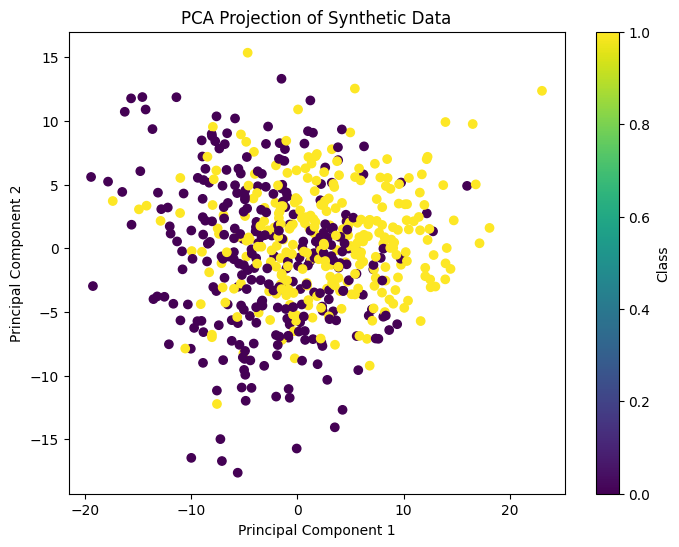

In [3]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA Projection of Synthetic Data')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Class')
plt.show()


Розділення на тренувальні і тестові дані. Розрахунок апріорних імовірностей класів у y_train

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, stratify=y, random_state=42)

unique_classes, counts = np.unique(y_train, return_counts=True)
priors_from_y = counts / counts.sum()

prior_class_df = pd.DataFrame({
    "Клас": unique_classes,
    "Кількість": counts,
    "Апріорна ймовірність": priors_from_y
})

display(prior_class_df)


,Клас,Кількість,Апріорна ймовірність
0,0,229,0.503297
1,1,226,0.496703


Кластеризація GMM

In [5]:
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_train)
initial_weights = gmm.weights_
prior_class_df['gmm_weights'] = initial_weights

display(prior_class_df)


,Клас,Кількість,Апріорна ймовірність,gmm_weights
0,0,229,0.503297,0.518967
1,1,226,0.496703,0.481033


In [6]:
gnb = GaussianNB(priors=initial_weights)
gnb.fit(X_train, y_train)
y_pred_gmm = gnb.predict(X_test)

f1_gmm = f1_score(y_test, y_pred_gmm)


Класифікація: логістична регресія вручну (градієнтний спуск)

In [7]:
def sigmoid(z): return 1 / (1 + np.exp(-z))
def binary_cross_entropy(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-8) + (1 - y_true) * np.log(1 - y_pred + 1e-8))

def logistic_regression_train(X, y, lr=0.01, epochs=100):
    weights = np.zeros(X.shape[1])
    bias = 0
    for _ in range(epochs):
        z = np.dot(X, weights) + bias
        y_pred = sigmoid(z)
        dw = np.dot(X.T, (y_pred - y)) / len(y)
        db = np.mean(y_pred - y)
        weights -= lr * dw
        bias -= lr * db
    return weights, bias

def logistic_regression_predict(X, weights, bias):
    return (sigmoid(np.dot(X, weights) + bias) >= 0.5).astype(int)

X_train_norm = (X_train - np.mean(X_train, axis=0)) / np.std(X_train, axis=0)
X_test_norm = (X_test - np.mean(X_test, axis=0)) / np.std(X_test, axis=0)
weights, bias = logistic_regression_train(X_train_norm, y_train)
y_pred_lr = logistic_regression_predict(X_test_norm, weights, bias)
f1_lr = f1_score(y_test, y_pred_lr)


Генетичний алгоритм для логістичної регресії

In [8]:
def fitness_func(ga_instance, solution, _):
    preds = sigmoid(np.dot(X_train_norm, solution))
    return accuracy_score(y_train, (preds >= 0.5).astype(int))

ga = pygad.GA(num_generations=50,
              num_parents_mating=10,
              fitness_func=fitness_func,
              sol_per_pop=30,
              num_genes=X_train_norm.shape[1])
ga.run()
best_weights = ga.best_solution()[0]
y_pred_ga = (sigmoid(np.dot(X_test_norm, best_weights)) >= 0.5).astype(int)
f1_ga = f1_score(y_test, y_pred_ga)

dataframe=pd.DataFrame({
    'Model': ['GMM + GNB', 'Logistic Regression (GD)', 'Logistic Regression (GA)'],
    'F1 Score': [f1_gmm, f1_lr, f1_ga]
})


/usr/local/lib/python3.11/dist-packages/pygad/utils/validation.py:966: UserWarning: The percentage of genes to mutate (mutation_percent_genes=10) resulted in selecting (0) genes. The number of genes to mutate is set to 1 (mutation_num_genes=1).
If you do not want to mutate any gene, please set mutation_type=None.
  warnings.warn(


In [9]:
dataframe

,Model,F1 Score
0,GMM + GNB,0.730435
1,Logistic Regression (GD),0.714286
2,Logistic Regression (GA),0.690265


---
# Виконання домашнього завдання
## Класифікація Breast Cancer Wisconsin (Diagnostic): кластеризація, PCA та оптимізація параметрів логістичної регресії (градієнтний спуск і генетичний алгоритм)

**План роботи:**
1. Завантаження даних
2. Попарні точкові діаграми ознак з цільовою змінною
3. Кластеризація (Spectral, k-means, GMM) і порівняння з фактичними класами
4. Зменшення розмірності методом PCA
5. Точкова діаграма класів у новому просторі ознак
6. Логістична регресія `sklearn.linear_model.LogisticRegression`
7. Логістична регресія з оптимізацією параметрів методами градієнтного спуску (GD, SGD, Mini-batch, Momentum, Nesterov, AdaGrad, RMSProp, Adam)
8. Логістична регресія з оптимізацією параметрів генетичним алгоритмом (PyGAD)
9. Оцінка якості кожного класифікатора: `confusion_matrix()`, `f1_score()`
10. Загальні висновки

## Крок 1. Завантаження даних

In [10]:
!pip install -q pygad

In [11]:
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pygad

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (confusion_matrix, f1_score, accuracy_score, precision_score, recall_score,
                             adjusted_rand_score, ConfusionMatrixDisplay, log_loss)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)

In [12]:
# Завантаження набору даних
data = load_breast_cancer()

# Ознаки
X = data.data
# Цільова змінна (0 - злоякісна, 1 - доброякісна)
y = data.target

feature_names = data.feature_names
target_names = data.target_names        # ['malignant', 'benign']

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['diagnosis'] = df['target'].map({0: 'malignant (0)', 1: 'benign (1)'})

print('Розмір X:', X.shape, '| розмір y:', y.shape)
print('Класи:', dict(zip(target_names, np.bincount(y))))
print('Пропуски:', df.isna().sum().sum())
df.head()

Розмір X: (569, 30) | розмір y: (569,)
Класи: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Пропуски: 0


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant (0)
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant (0)
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant (0)
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant (0)
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant (0)


In [13]:
df[feature_names].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


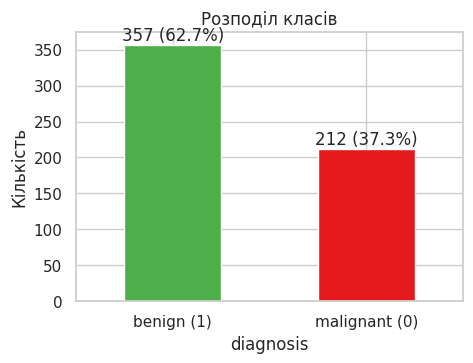

In [14]:
fig, ax = plt.subplots(figsize=(5, 3.5))
df['diagnosis'].value_counts().plot.bar(ax=ax, color=['#4daf4a', '#e41a1c'])
ax.set_title('Розподіл класів'); ax.set_ylabel('Кількість'); plt.xticks(rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} ({p.get_height() / len(df):.1%})',
                (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom')
plt.show()

**Опис даних:** 569 зразків (ядер клітин з цифрових зображень тонкоголкової біопсії), **30 дійсних ознак** без пропусків.
Ознаки — 10 базових характеристик ядра (radius, texture, perimeter, area, smoothness, compactness, concavity,
concave points, symmetry, fractal dimension), кожна у трьох варіантах: `mean` (середнє), `error` (стандартна похибка) і `worst` (середнє трьох найбільших значень).
Ознаки мають дуже різні масштаби (від ~0.001 у `fractal dimension error` до ~4250 у `worst area`), тому для більшості методів потрібна стандартизація.
Класи помірно незбалансовані: **212 злоякісних (37%) і 357 доброякісних (63%)**.

## Крок 2. Попарні точкові діаграми розподілу цільової змінної з ознаками

30 ознак дають 435 пар — такий pairplot нечитабельний. Тому:
1. оцінюємо зв'язок кожної ознаки з цільовою змінною (кореляція та розподіл за класами для всіх 30 ознак);
2. будуємо попарні точкові діаграми (pairplot) для 6 найінформативніших ознак з кольоровим розділенням за класом.

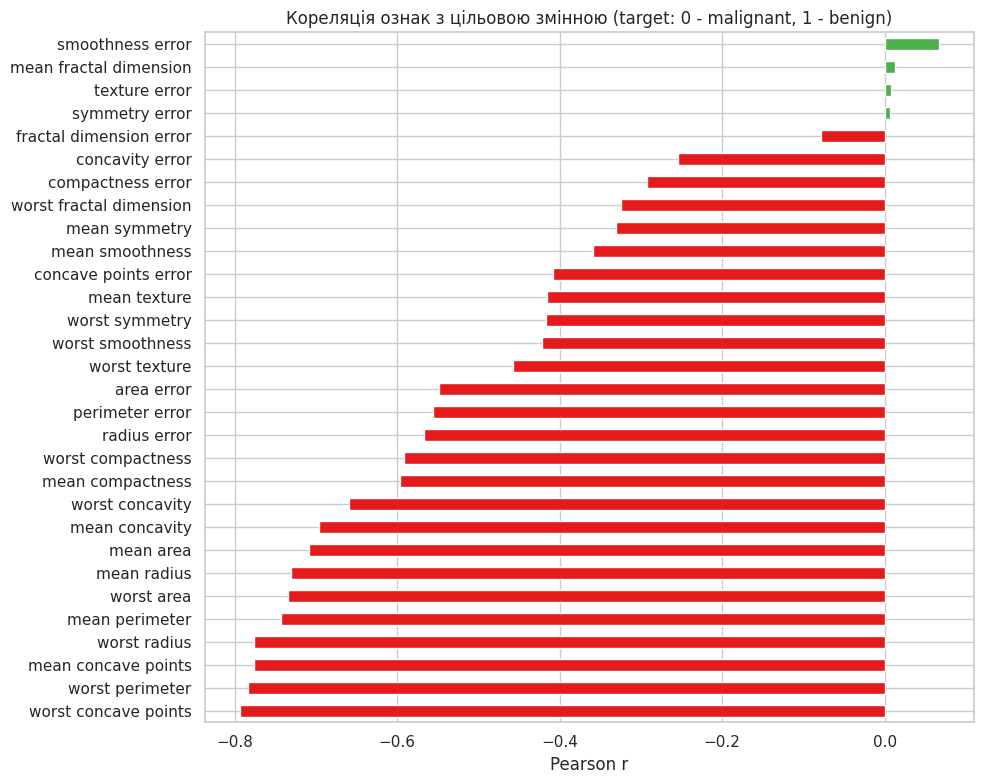

In [15]:
corr_target = df[feature_names].corrwith(df['target']).sort_values()
plt.figure(figsize=(10, 8))
colors = ['#e41a1c' if v < 0 else '#4daf4a' for v in corr_target]
corr_target.plot.barh(color=colors)
plt.title('Кореляція ознак з цільовою змінною (target: 0 - malignant, 1 - benign)')
plt.xlabel('Pearson r')
plt.tight_layout(); plt.show()

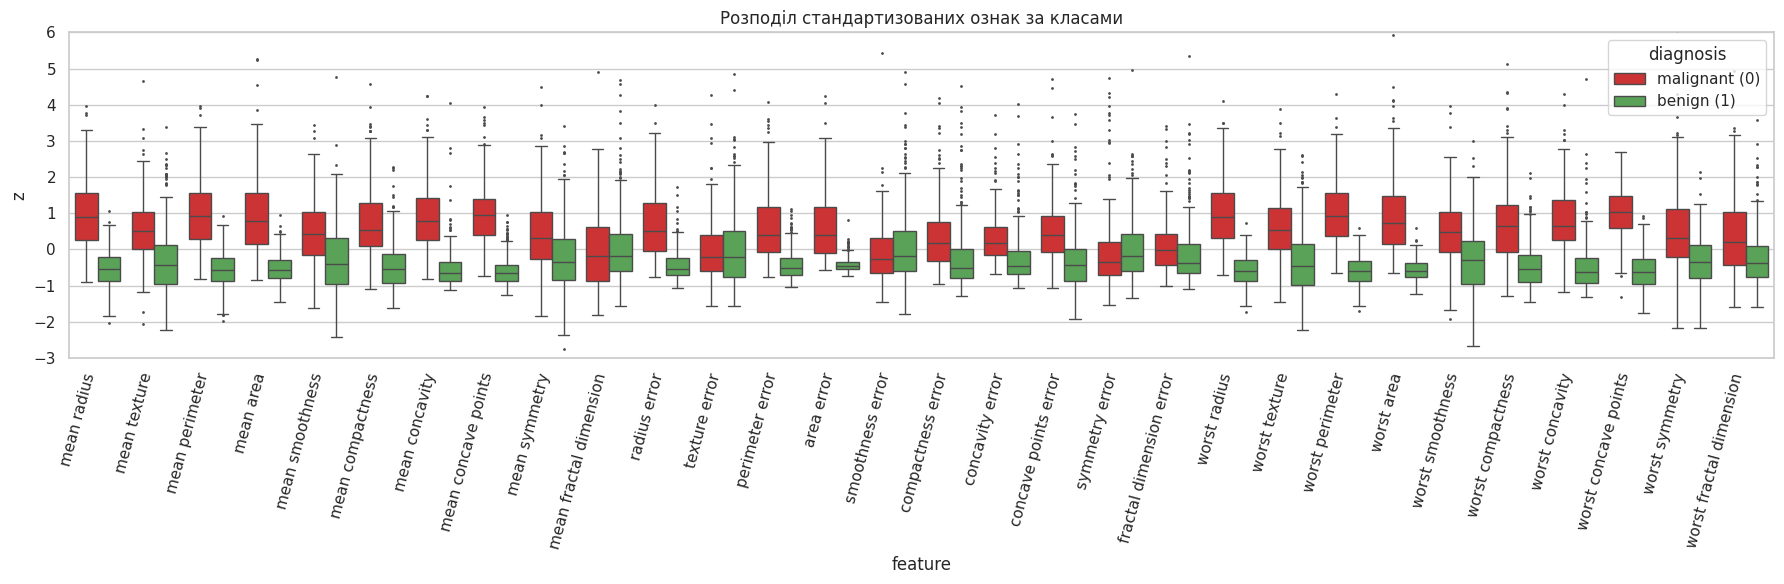

In [16]:
# Розподіли всіх 30 стандартизованих ознак за класами
df_std = pd.DataFrame(StandardScaler().fit_transform(df[feature_names]), columns=feature_names)
df_long = df_std.assign(diagnosis=df['diagnosis']).melt(id_vars='diagnosis', var_name='feature', value_name='z')
plt.figure(figsize=(18, 6))
sns.boxplot(data=df_long, x='feature', y='z', hue='diagnosis', palette={'malignant (0)': '#e41a1c', 'benign (1)': '#4daf4a'},
            fliersize=1)
plt.xticks(rotation=75, ha='right'); plt.ylim(-3, 6)
plt.title('Розподіл стандартизованих ознак за класами')
plt.tight_layout(); plt.show()

6 найбільш корельованих з target ознак: ['worst concave points', 'worst perimeter', 'mean concave points', 'worst radius', 'mean perimeter', 'worst area']


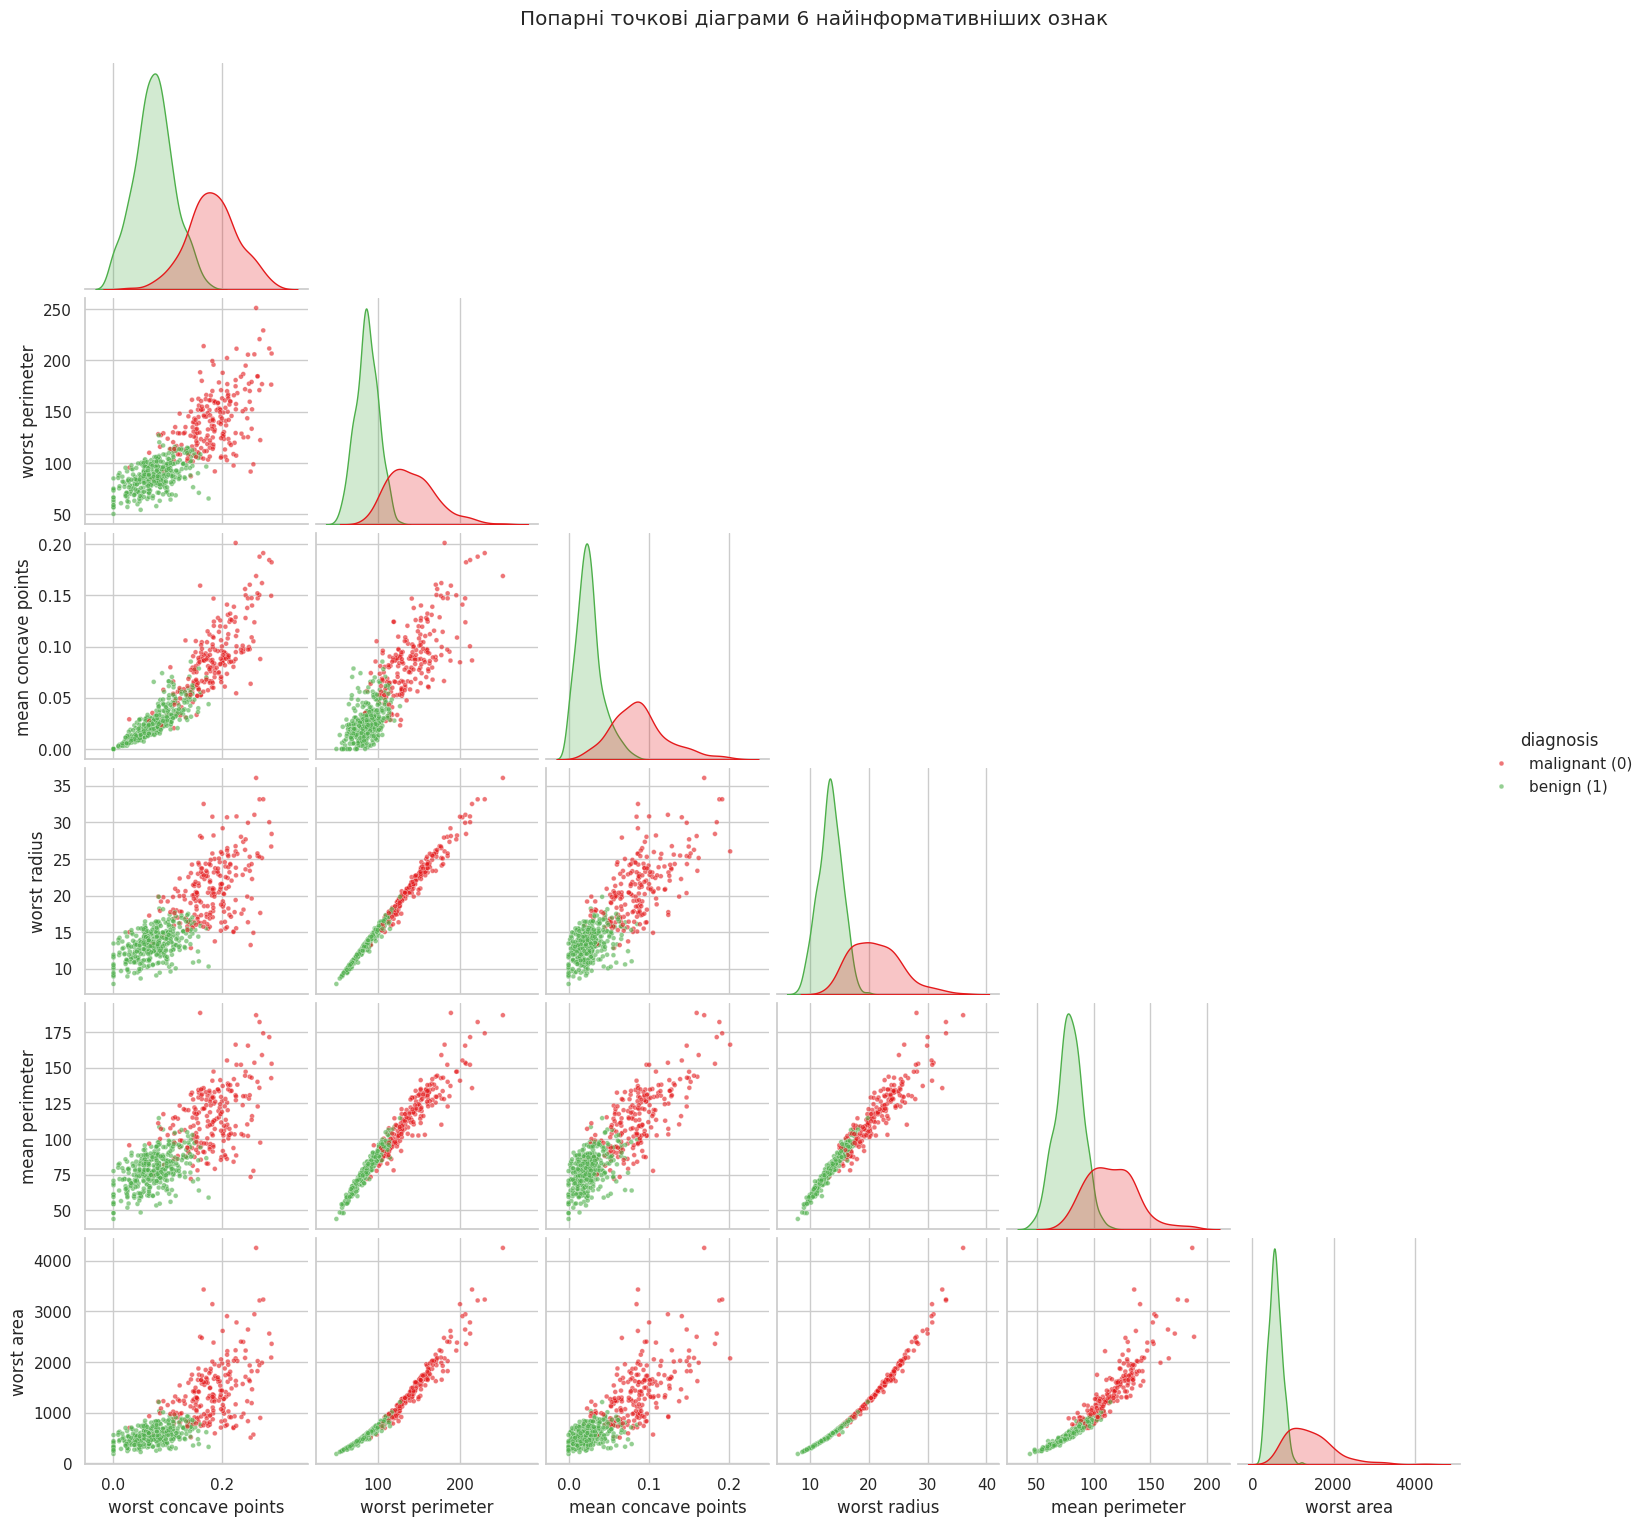

In [17]:
top_features = corr_target.abs().sort_values(ascending=False).index[:6].tolist()
print('6 найбільш корельованих з target ознак:', top_features)

g = sns.pairplot(df[top_features + ['diagnosis']], hue='diagnosis', corner=True, diag_kind='kde',
                 palette={'malignant (0)': '#e41a1c', 'benign (1)': '#4daf4a'},
                 plot_kws={'s': 12, 'alpha': 0.6})
g.fig.suptitle('Попарні точкові діаграми 6 найінформативніших ознак', y=1.02)
plt.show()

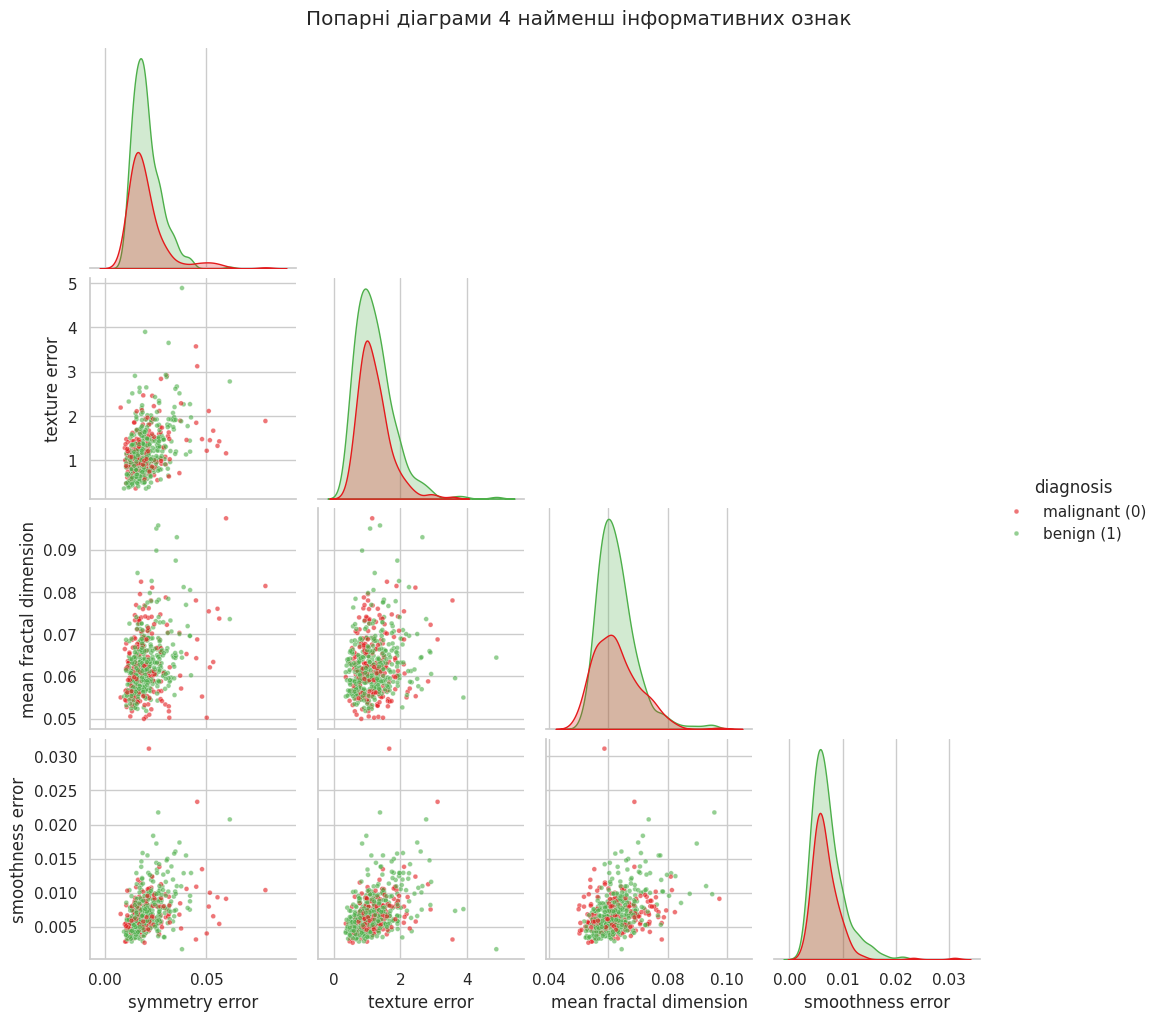

In [18]:
# Ознаки з найслабшим зв'язком з target — для контрасту
weak_features = corr_target.abs().sort_values().index[:4].tolist()
g = sns.pairplot(df[weak_features + ['diagnosis']], hue='diagnosis', corner=True, diag_kind='kde',
                 palette={'malignant (0)': '#e41a1c', 'benign (1)': '#4daf4a'}, plot_kws={'s': 12, 'alpha': 0.6})
g.fig.suptitle('Попарні діаграми 4 найменш інформативних ознак', y=1.02)
plt.show()

**Висновки кроку 2:**
- Найсильніше пов'язані з діагнозом ознаки **розміру та форми ядра**: `worst concave points` (|r| ≈ 0.79), `worst perimeter`,
  `mean concave points`, `worst radius`, `mean perimeter`, `worst area` (|r| ≈ 0.73–0.78). Кореляція від'ємна: чим більше й «нерівніше» ядро,
  тим імовірніше злоякісна пухлина (клас 0).
- На попарних діаграмах цих ознак класи **добре розділяються** (злоякісні — праворуч/вгорі), хоча є зона перекриття.
  Ознаки `radius`/`perimeter`/`area` майже лінійно залежать одна від одної (сильна мультиколінеарність) — це ознака надлишковості,
  яку усуває PCA.
- Ознаки `symmetry error`, `texture error`, `mean fractal dimension`, `smoothness error` (|r| < 0.07) майже не пов'язані з класом —
  розподіли класів на їх діаграмах повністю перекриваються.
- Отже, задача близька до **лінійно роздільної**, і лінійний класифікатор (логістична регресія) має працювати добре.

## Крок 3. Кластеризація: Spectral Clustering, k-means, GMM

Кластеризацію виконуємо на **стандартизованих** ознаках (без використання міток класів), з кількістю кластерів = 2.
Оскільки номер кластера довільний, кожен кластер зіставляємо з класом, що в ньому переважає (majority mapping).
Якість порівняння оцінюємо таблицею спряженості, **ARI** (Adjusted Rand Index), accuracy та F1 після зіставлення.

In [19]:
X_std = StandardScaler().fit_transform(X)

clusterers = {
    'k-means': KMeans(n_clusters=2, n_init=20, random_state=RANDOM_STATE),
    'Spectral (RBF, gamma=0.02)': SpectralClustering(n_clusters=2, affinity='rbf', gamma=0.02, random_state=RANDOM_STATE),
    'Spectral (RBF, gamma=0.001)': SpectralClustering(n_clusters=2, affinity='rbf', gamma=0.001, random_state=RANDOM_STATE),
    'Spectral (kNN)': SpectralClustering(n_clusters=2, affinity='nearest_neighbors', n_neighbors=15,
                                         assign_labels='cluster_qr', random_state=RANDOM_STATE),
    'GMM (full)': GaussianMixture(n_components=2, covariance_type='full', n_init=10, random_state=RANDOM_STATE),
    'GMM (diag)': GaussianMixture(n_components=2, covariance_type='diag', n_init=10, random_state=RANDOM_STATE),
}

def map_clusters_to_classes(labels, y_true):
    mapping = {c: np.bincount(y_true[labels == c]).argmax() for c in np.unique(labels)}
    return np.vectorize(mapping.get)(labels)

cluster_labels, cluster_rows = {}, []
for name, model in clusterers.items():
    labels = model.fit_predict(X_std)
    mapped = map_clusters_to_classes(labels, y)
    cluster_labels[name] = mapped
    cluster_rows.append({'method': name,
                         'cluster sizes': sorted(np.bincount(labels).tolist()),
                         'ARI': adjusted_rand_score(y, labels),
                         'accuracy': accuracy_score(y, mapped),
                         'F1 (benign)': f1_score(y, mapped),
                         'F1 (malignant)': f1_score(y, mapped, pos_label=0)})
cluster_res = pd.DataFrame(cluster_rows)
cluster_res.round(3)

,method,cluster sizes,ARI,accuracy,F1 (benign),F1 (malignant)
0,k-means,"[189, 380]",0.671,0.910,0.931,0.873
1,"Spectral (RBF, gamma=0.02)","[2, 567]",0.005,0.631,0.773,0.019
2,"Spectral (RBF, gamma=0.001)","[190, 379]",0.665,0.909,0.929,0.871
3,Spectral (kNN),"[198, 371]",0.749,0.933,0.948,0.907
4,GMM (full),"[214, 355]",0.774,0.940,0.952,0.920
5,GMM (diag),"[224, 345]",0.678,0.912,0.929,0.885


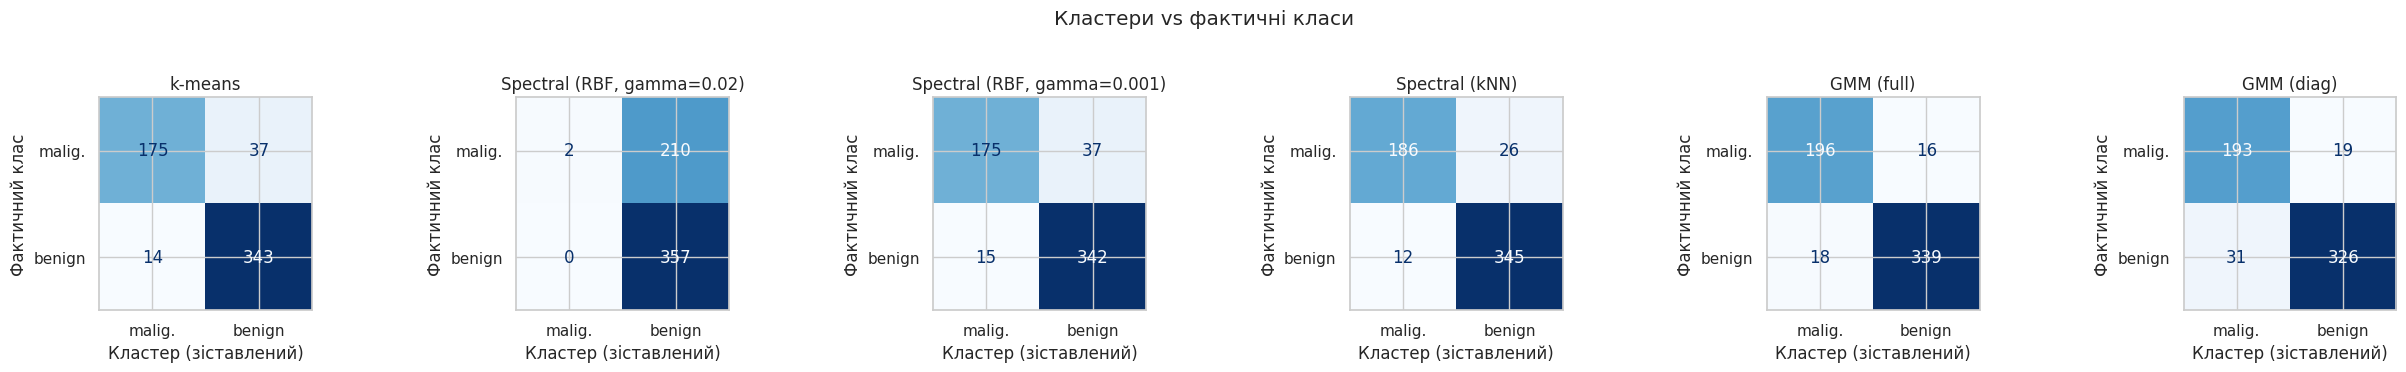

In [20]:
fig, axes = plt.subplots(1, len(cluster_labels), figsize=(4.2 * len(cluster_labels), 3.6))
for ax, (name, mapped) in zip(axes, cluster_labels.items()):
    ConfusionMatrixDisplay(confusion_matrix(y, mapped), display_labels=['malig.', 'benign']).plot(
        ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(name); ax.set_xlabel('Кластер (зіставлений)'); ax.set_ylabel('Фактичний клас')
plt.suptitle('Кластери vs фактичні класи', y=1.03)
plt.tight_layout(); plt.show()

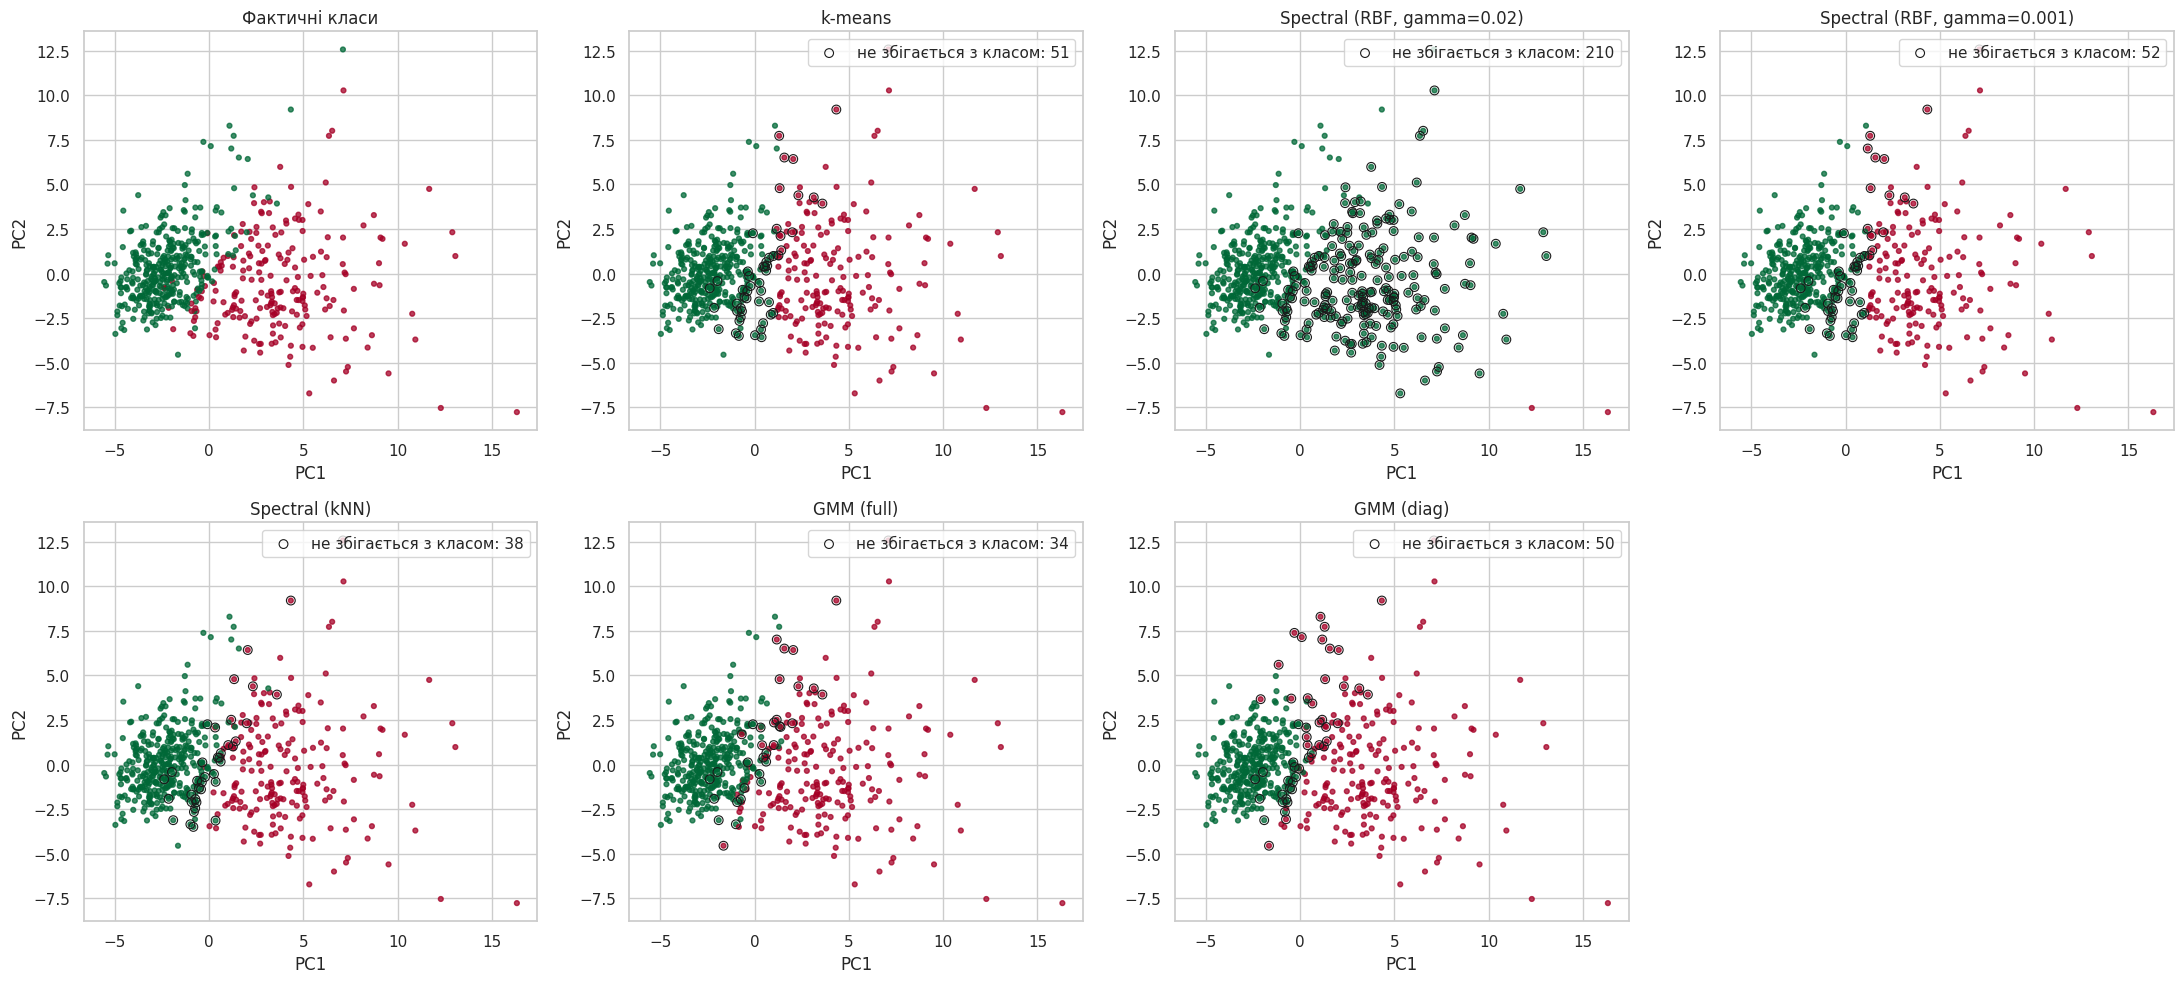

In [21]:
# Візуалізація кластерів у просторі двох перших головних компонент (детальніше про PCA — крок 4)
X_2d = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_std)
panels = [('Фактичні класи', y)] + list(cluster_labels.items())
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
for ax, (title, lab) in zip(axes.ravel(), panels):
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=lab, cmap='RdYlGn', s=12, alpha=0.75)
    if title != 'Фактичні класи':
        wrong = lab != y
        ax.scatter(X_2d[wrong, 0], X_2d[wrong, 1], facecolors='none', edgecolors='k', s=40, lw=0.8,
                   label=f'не збігається з класом: {wrong.sum()}')
        ax.legend(loc='upper right')
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
for ax in axes.ravel()[len(panels):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

**Висновки кроку 3:**
- Без жодної інформації про мітки всі коректно налаштовані методи виділили 2 кластери, які **добре відповідають діагнозу**:
  точність після зіставлення 91–94%, ARI 0.67–0.77.
- **GMM (full)** — найкращий результат (ARI ≈ 0.77, accuracy ≈ 94%, розміри кластерів 214/355 майже як класи 212/357):
  повна коваріаційна матриця враховує сильні кореляції між ознаками та еліпсоїдну форму кластерів.
  GMM з діагональною коваріацією (ігнорує кореляції) помітно гірший (ARI ≈ 0.68).
- **Spectral (kNN-граф)** — другий результат (ARI ≈ 0.75): граф найближчих сусідів добре описує локальну структуру даних.
- **k-means** (ARI ≈ 0.67): припускає сферичні кластери однакового розміру, тому частину доброякісних зразків з великими ядрами
  відносить до «злоякісного» кластера.
- **Spectral (RBF)** дуже чутлива до параметра `gamma`: при `gamma=0.02` граф подібності розпадається, і алгоритм відокремлює
  лише 2 точки-викиди (ARI ≈ 0) — кластеризація не вдалась; при `gamma=0.001` результат рівний k-means.
- Помилки всіх методів зосереджені в **зоні перекриття класів** (центр діаграми PC1–PC2): це «дрібні, але злоякісні» або
  «великі, але доброякісні» зразки. Кластеризація знаходить природні групи за схожістю, а не за діагнозом, тому повного збігу
  бути не може, але високий ARI підтверджує, що класи утворюють компактні групи — хороший знак для класифікації.

## Крок 4. Зменшення розмірності методом PCA

PCA чутливий до масштабу, тому застосовуємо його до стандартизованих ознак. Щоб уникнути «витоку» інформації з тестової вибірки,
спочатку ділимо дані на train/test (80/20, зі стратифікацією), а `StandardScaler` і `PCA` навчаємо **лише на train**.

Train: (455, 30) [170 285] | Test: (114, 30) [42 72]


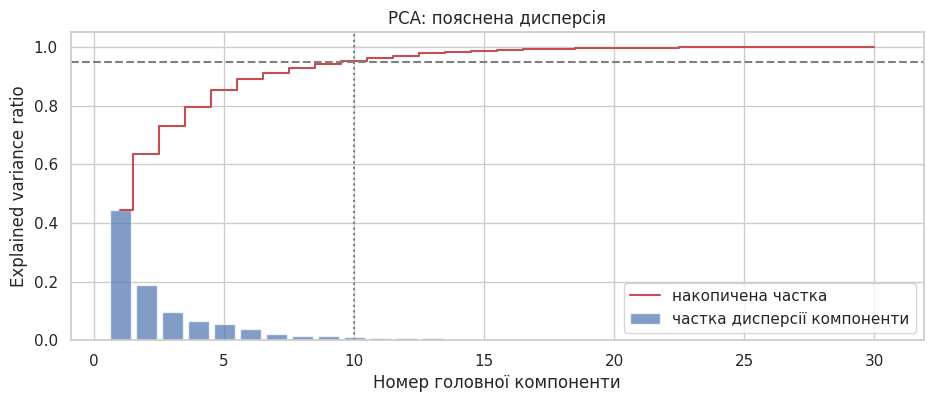

Пояснена дисперсія PC1, PC2: [0.444 0.189] -> разом 0.634
Компонент для 95% дисперсії: 10
Накопичена дисперсія для 2, 3, 5, 10 компонент: [0.634 0.729 0.851 0.953]


In [22]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

scaler = StandardScaler().fit(X_train_raw)
X_train = scaler.transform(X_train_raw)
X_test = scaler.transform(X_test_raw)
print('Train:', X_train.shape, np.bincount(y_train), '| Test:', X_test.shape, np.bincount(y_test))

pca_full = PCA(random_state=RANDOM_STATE).fit(X_train)
evr = pca_full.explained_variance_ratio_
cum = np.cumsum(evr)
n_95 = int(np.argmax(cum >= 0.95) + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(range(1, 31), evr, alpha=0.7, label='частка дисперсії компоненти')
ax.step(range(1, 31), cum, where='mid', color='r', label='накопичена частка')
ax.axhline(0.95, ls='--', color='gray'); ax.axvline(n_95, ls=':', color='gray')
ax.set_xlabel('Номер головної компоненти'); ax.set_ylabel('Explained variance ratio')
ax.set_title('PCA: пояснена дисперсія'); ax.legend()
plt.show()

print('Пояснена дисперсія PC1, PC2:', evr[:2].round(3), '-> разом', cum[1].round(3))
print(f'Компонент для 95% дисперсії: {n_95}')
print('Накопичена дисперсія для 2, 3, 5, 10 компонент:', cum[[1, 2, 4, 9]].round(3))

Новий простір ознак: 30 -> 10 компонент (95.3% дисперсії)


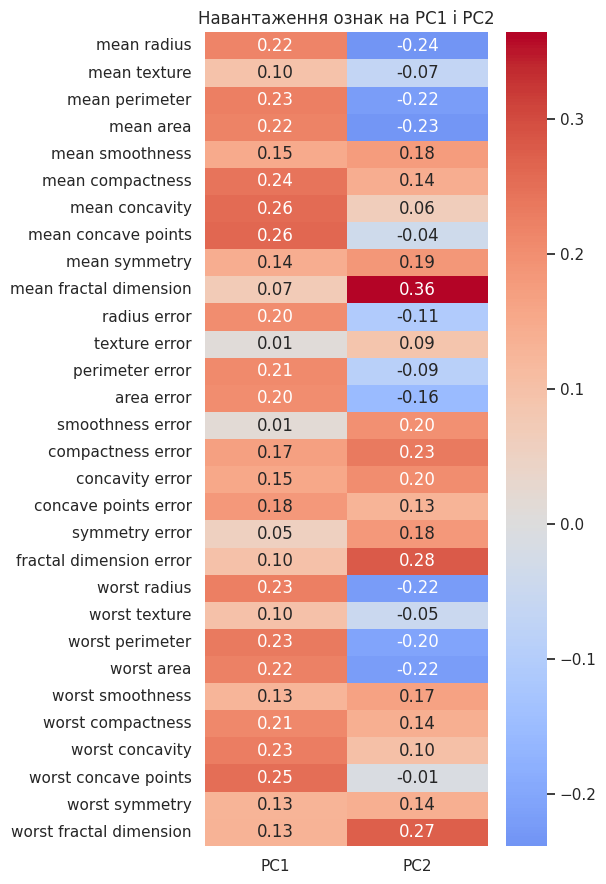

In [23]:
N_PCA = n_95
pca = PCA(n_components=N_PCA, random_state=RANDOM_STATE).fit(X_train)
X_train_pca = pca.transform(X_train)
X_test_pca = pca.transform(X_test)
print(f'Новий простір ознак: {X.shape[1]} -> {N_PCA} компонент '
      f'({pca.explained_variance_ratio_.sum():.1%} дисперсії)')

# Внесок вихідних ознак у перші дві компоненти
loadings = pd.DataFrame(pca.components_[:2].T, index=feature_names, columns=['PC1', 'PC2'])
plt.figure(figsize=(6, 9))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Навантаження ознак на PC1 і PC2')
plt.tight_layout(); plt.show()

**Висновки кроку 4:**
- Перша головна компонента пояснює **44.4%** дисперсії, друга — **18.9%** (разом 63.4%); 3 компоненти — 72.9%, 5 — 85.1%.
- Для збереження **95%** дисперсії достатньо **10 компонент** з 30 — розмірність зменшується втричі, бо вихідні ознаки сильно корельовані.
- **PC1** має додатні навантаження майже на всі ознаки «розміру та нерівності» (radius, perimeter, area, concavity, concave points) —
  це «загальний розмір/злоякісність» ядра. **PC2** протиставляє ознаки розміру (від'ємні навантаження) ознакам фрактальної
  розмірності, гладкості та симетрії (додатні) — це «текстура/форма незалежно від розміру».
- Далі використовуємо простір **PCA-10** для моделювання та PC1–PC2 для візуалізації.

## Крок 5. Точкова діаграма розподілу за класами у новому просторі ознак

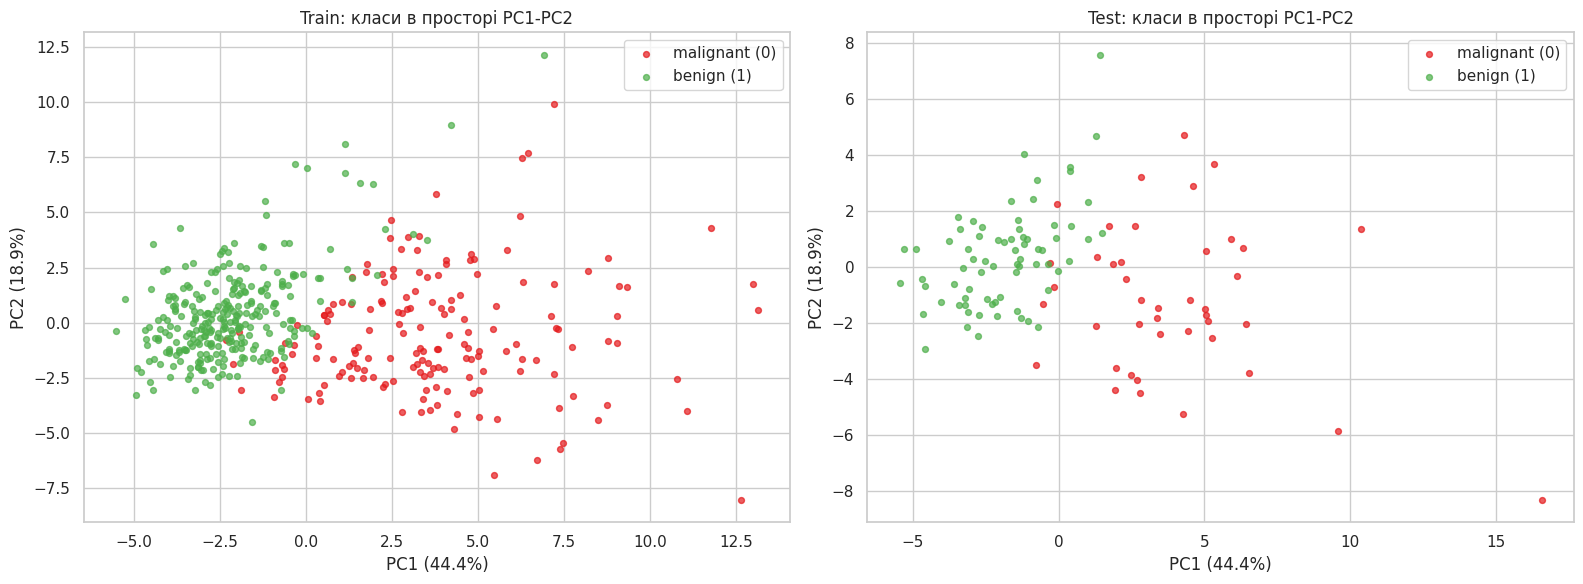

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (Xp, yp, title) in zip(axes, [(X_train_pca, y_train, 'Train'), (X_test_pca, y_test, 'Test')]):
    for cls, color, name in [(0, '#e41a1c', 'malignant (0)'), (1, '#4daf4a', 'benign (1)')]:
        ax.scatter(Xp[yp == cls, 0], Xp[yp == cls, 1], c=color, s=18, alpha=0.7, label=name)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.set_title(f'{title}: класи в просторі PC1-PC2'); ax.legend()
plt.tight_layout(); plt.show()

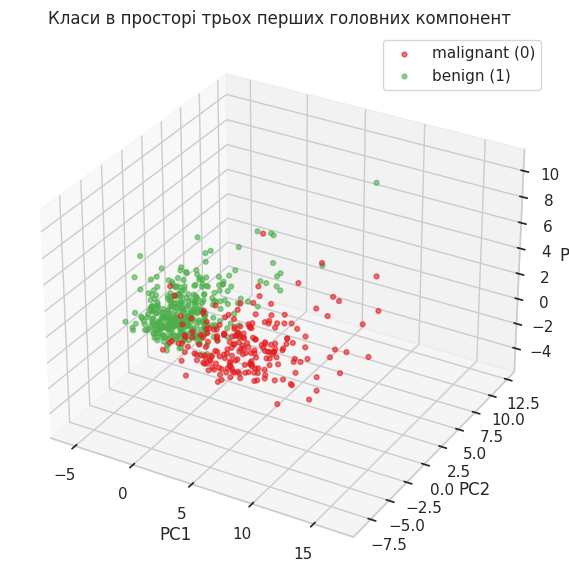

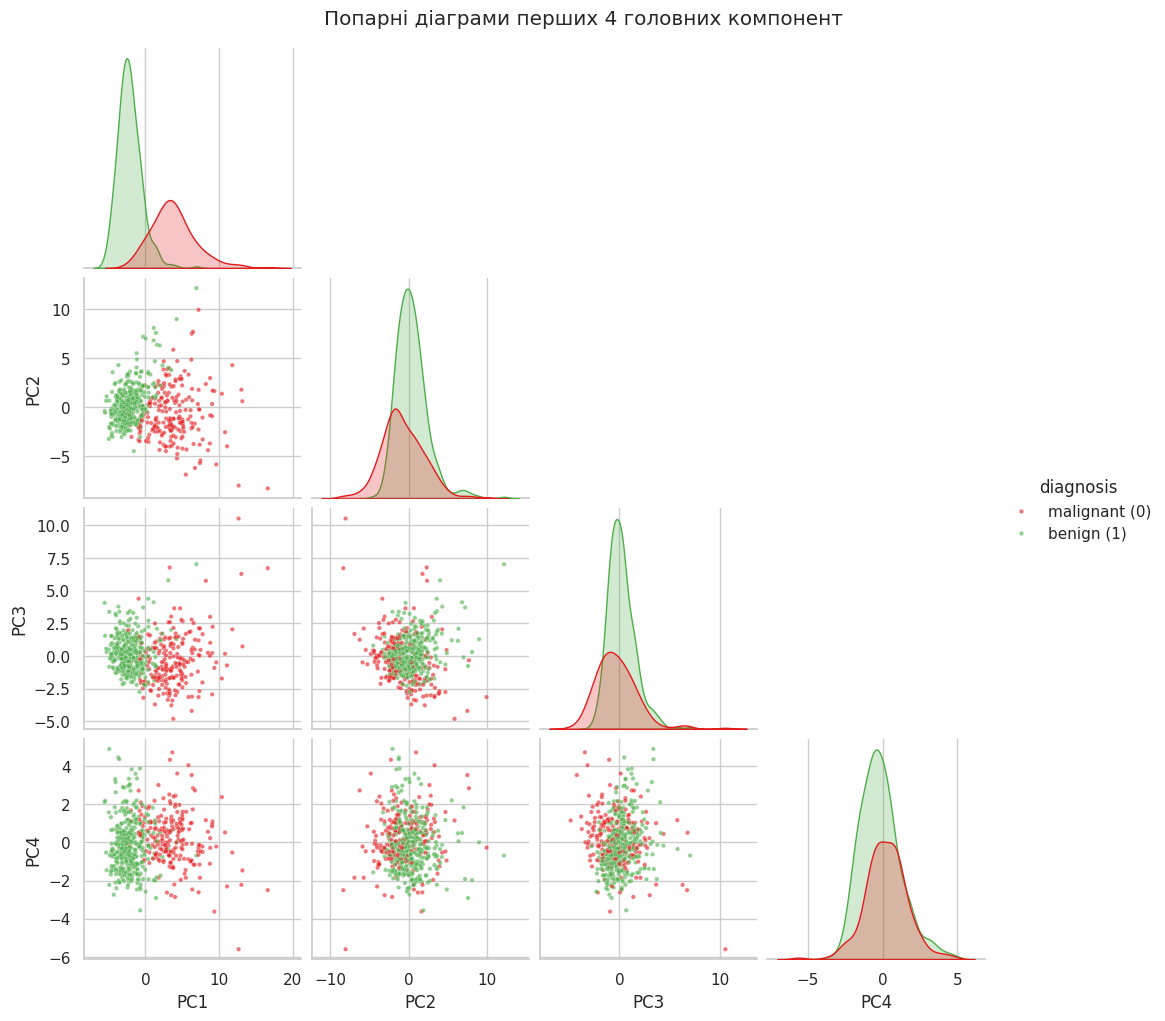

In [25]:
from mpl_toolkits.mplot3d import Axes3D  # noqa
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')
Xall_pca = pca.transform(scaler.transform(X))
for cls, color, name in [(0, '#e41a1c', 'malignant (0)'), (1, '#4daf4a', 'benign (1)')]:
    ax.scatter(*Xall_pca[y == cls, :3].T, c=color, s=12, alpha=0.6, label=name)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_zlabel('PC3'); ax.legend()
ax.set_title('Класи в просторі трьох перших головних компонент')
plt.show()

g = sns.pairplot(pd.DataFrame(Xall_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4']).assign(diagnosis=df['diagnosis']),
                 hue='diagnosis', corner=True, palette={'malignant (0)': '#e41a1c', 'benign (1)': '#4daf4a'},
                 plot_kws={'s': 10, 'alpha': 0.6})
g.fig.suptitle('Попарні діаграми перших 4 головних компонент', y=1.02)
plt.show()

**Висновки кроку 5:** у просторі PC1–PC2 класи **майже лінійно розділені**: доброякісні зразки утворюють компактну щільну
групу зліва (малі PC1), злоякісні — розкидану «хмару» праворуч (великі PC1). Розділення відбувається переважно вздовж **PC1**,
PC2 додає мало інформації. Зона перекриття невелика — саме тут помиляються і кластеризація, і класифікатори.
На тестовій вибірці картина та сама, що й на тренувальній (PCA навчено лише на train) — перенавчання PCA немає.
Наступні компоненти (PC3, PC4) класи практично не розділяють.

## Крок 6. Класифікація методом `LogisticRegression` (sklearn)

Навчаємо модель на двох варіантах простору ознак: усі 30 стандартизованих ознак та PCA-простір.
Для зручного оцінювання (крок 9) збираємо всі передбачення в словник `predictions`.

In [26]:
predictions = {}     # назва моделі -> передбачення на test
train_info = {}      # назва моделі -> додаткова інформація (час, втрати)

def evaluate_short(name, y_pred):
    print(f'{name:45s} accuracy = {accuracy_score(y_test, y_pred):.4f}   F1 = {f1_score(y_test, y_pred):.4f}')

for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    lr_tmp = LogisticRegression(C=C, max_iter=5000).fit(X_train, y_train)
    evaluate_short(f'sklearn LR, 30 ознак, C={C}', lr_tmp.predict(X_test))

sklearn LR, 30 ознак, C=0.01                  accuracy = 0.9474   F1 = 0.9595
sklearn LR, 30 ознак, C=0.1                   accuracy = 0.9737   F1 = 0.9793
sklearn LR, 30 ознак, C=1.0                   accuracy = 0.9825   F1 = 0.9861
sklearn LR, 30 ознак, C=10.0                  accuracy = 0.9649   F1 = 0.9722
sklearn LR, 30 ознак, C=100.0                 accuracy = 0.9474   F1 = 0.9577


In [27]:
t = time.time()
lr_sk = LogisticRegression(C=1.0, max_iter=5000, solver='lbfgs').fit(X_train, y_train)
train_info['sklearn LR (30 ознак)'] = {'time_s': time.time() - t,
                                       'train_loss': log_loss(y_train, lr_sk.predict_proba(X_train)[:, 1])}
predictions['sklearn LR (30 ознак)'] = lr_sk.predict(X_test)

t = time.time()
lr_sk_pca = LogisticRegression(C=1.0, max_iter=5000).fit(X_train_pca, y_train)
train_info[f'sklearn LR (PCA-{N_PCA})'] = {'time_s': time.time() - t,
                                           'train_loss': log_loss(y_train, lr_sk_pca.predict_proba(X_train_pca)[:, 1])}
predictions[f'sklearn LR (PCA-{N_PCA})'] = lr_sk_pca.predict(X_test_pca)

lr_sk_pca2 = LogisticRegression(C=1.0, max_iter=5000).fit(X_train_pca[:, :2], y_train)
predictions['sklearn LR (PCA-2)'] = lr_sk_pca2.predict(X_test_pca[:, :2])

for name in predictions:
    evaluate_short(name, predictions[name])
print('Кількість ітерацій lbfgs:', lr_sk.n_iter_)

sklearn LR (30 ознак)                         accuracy = 0.9825   F1 = 0.9861
sklearn LR (PCA-10)                           accuracy = 0.9737   F1 = 0.9790
sklearn LR (PCA-2)                            accuracy = 0.9474   F1 = 0.9577
Кількість ітерацій lbfgs: [19]


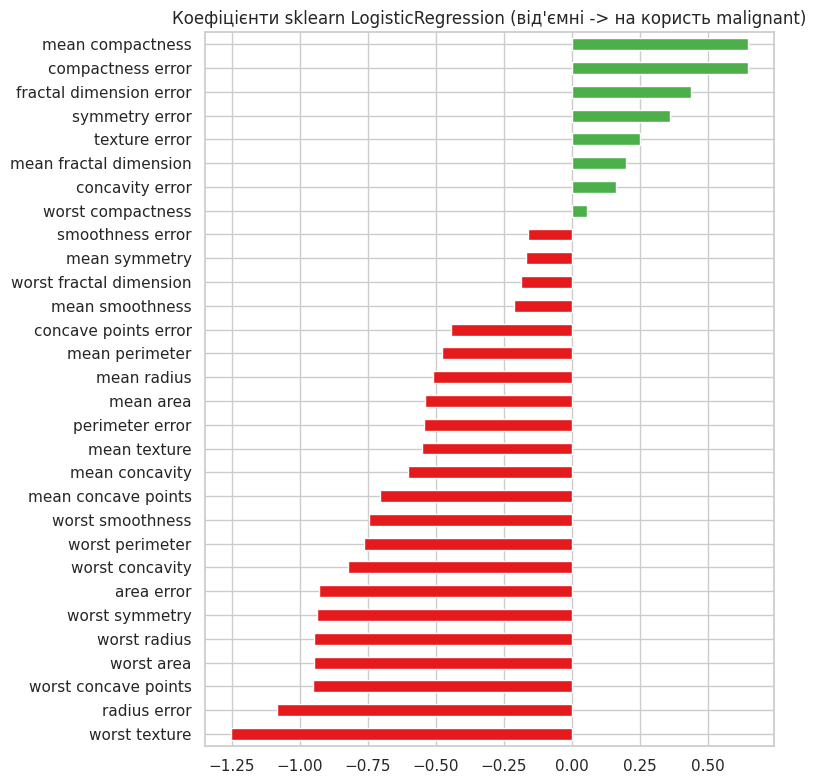

In [28]:
# Найбільш вагомі ознаки моделі (стандартизовані ознаки -> коефіцієнти можна порівнювати)
coef = pd.Series(lr_sk.coef_[0], index=feature_names).sort_values()
plt.figure(figsize=(8, 8))
coef.plot.barh(color=['#e41a1c' if c < 0 else '#4daf4a' for c in coef])
plt.title('Коефіцієнти sklearn LogisticRegression (від\'ємні -> на користь malignant)')
plt.tight_layout(); plt.show()

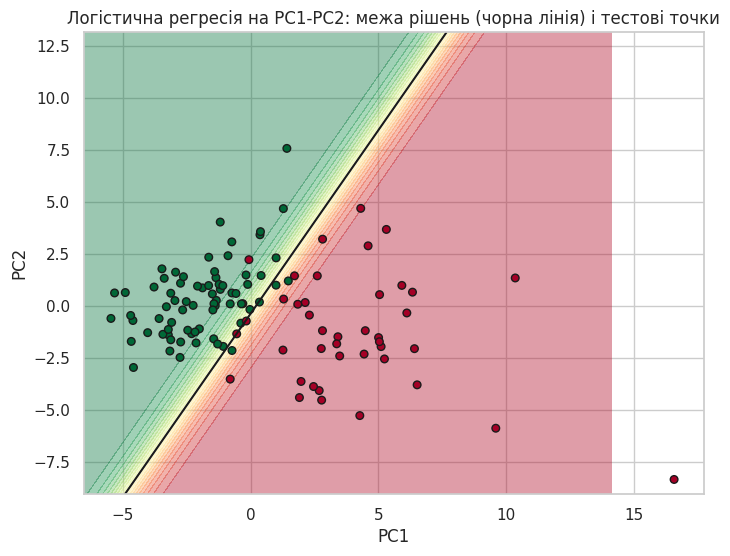

In [29]:
# Межа рішень у просторі PC1-PC2
xx, yy = np.meshgrid(np.linspace(X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1, 300),
                     np.linspace(X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1, 300))
zz = lr_sk_pca2.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, zz, levels=20, cmap='RdYlGn', alpha=0.4)
plt.contour(xx, yy, zz, levels=[0.5], colors='k')
plt.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap='RdYlGn', edgecolors='k', s=30)
plt.title('Логістична регресія на PC1-PC2: межа рішень (чорна лінія) і тестові точки')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.show()

**Висновки кроку 6:**
- `LogisticRegression` (lbfgs, `C=1`) на 30 стандартизованих ознаках: **accuracy = 98.25%, F1 = 0.986** на тесті
  (з 114 тестових зразків помилка лише у 2). Розв'язувач lbfgs (квазіньютонівський метод другого порядку) збігся всього за 19 ітерацій.
- Сила регуляризації важлива: `C = 0.01` (сильна) — недонавчання (F1 ≈ 0.96), `C = 100` (слабка) — перенавчання (F1 ≈ 0.958); оптимум — `C ≈ 1`.
- У просторі PCA-10 якість трохи нижча (F1 ≈ 0.979), у PCA-2 — ще нижча (F1 ≈ 0.958), але й двох компонент вистачає для
  ≈ 95% точності — межа рішень на PC1–PC2 майже вертикальна, тобто класифікація відбувається переважно за PC1.
- Найбільші за модулем коефіцієнти — у ознак `worst texture`, `radius error`, `worst concave points`, `worst area`, `worst radius` (усі від'ємні) — вони найбільше
  «штовхають» прогноз до злоякісного класу.

## Крок 7. Логістична регресія з оптимізацією параметрів методами градієнтного спуску

**Модель:** $\hat{y} = \sigma(Xw + b)$, $\sigma(z) = \frac{1}{1+e^{-z}}$.
**Функція втрат** — бінарна крос-ентропія з L2-регуляризацією:
$$L(w,b) = -\frac{1}{m}\sum_{i=1}^{m}\big[y_i\ln\hat{y}_i + (1-y_i)\ln(1-\hat{y}_i)\big] + \frac{\lambda}{2}\|w\|^2$$
**Градієнт:** $\nabla_w L = \frac{1}{m}X^T(\hat{y}-y) + \lambda w$, $\quad \nabla_b L = \frac{1}{m}\sum(\hat{y}_i - y_i)$.

Реалізуємо (з нуля, на NumPy) методи з конспекту:

| Метод | Правило оновлення параметрів $\theta$ |
|---|---|
| **Batch GD** | $\theta \leftarrow \theta - \eta \nabla L(\theta)$ по всій вибірці |
| **SGD** | те саме, але градієнт по **одному** випадковому прикладу |
| **Mini-batch GD** | градієнт по міні-батчу (32 приклади) |
| **Momentum** | $v \leftarrow \beta v + \eta \nabla L$; $\theta \leftarrow \theta - v$ |
| **Nesterov (NAG)** | градієнт обчислюється в точці «заглядання вперед» $\theta - \beta v$ |
| **AdaGrad** | $G \leftarrow G + g^2$; $\theta \leftarrow \theta - \frac{\eta}{\sqrt{G}+\varepsilon} g$ |
| **RMSProp** | $E \leftarrow \rho E + (1-\rho) g^2$; $\theta \leftarrow \theta - \frac{\eta}{\sqrt{E}+\varepsilon} g$ |
| **Adam** | $m \leftarrow \beta_1 m + (1-\beta_1)g$, $v \leftarrow \beta_2 v + (1-\beta_2)g^2$, з корекцією зміщення; $\theta \leftarrow \theta - \eta\frac{\hat m}{\sqrt{\hat v}+\varepsilon}$ |

Параметри $\theta = (w, b)$ — 31 число (30 ваг + зсув). Для зручності додаємо до $X$ стовпець одиниць, тоді $b$ — останній елемент $\theta$.

In [30]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def add_bias(X):
    return np.hstack([X, np.ones((X.shape[0], 1))])

def bce_loss(theta, Xb, y, lam=0.0):
    p = sigmoid(Xb @ theta)
    eps = 1e-12
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps)) + 0.5 * lam * np.sum(theta[:-1] ** 2)

def bce_grad(theta, Xb, y, lam=0.0):
    p = sigmoid(Xb @ theta)
    g = Xb.T @ (p - y) / len(y)
    g[:-1] += lam * theta[:-1]          # зсув не регуляризуємо
    return g

def predict(theta, X):
    return (sigmoid(add_bias(X) @ theta) >= 0.5).astype(int)


class LogRegGD:
    """Логістична регресія з різними методами (стохастичного) градієнтного спуску."""
    def __init__(self, method='gd', lr=0.1, epochs=200, batch_size=None, beta=0.9, rho=0.9,
                 beta1=0.9, beta2=0.999, eps=1e-8, lam=1e-3, seed=RANDOM_STATE):
        self.__dict__.update(locals()); del self.__dict__['self']

    def fit(self, X, y):
        rng = np.random.default_rng(self.seed)
        Xb = add_bias(X); m, n = Xb.shape
        theta = np.zeros(n)
        v = np.zeros(n); s = np.zeros(n); t = 0
        bs = {'gd': m, 'sgd': 1}.get(self.method, self.batch_size or 32)
        if self.method in ('momentum', 'nesterov', 'adagrad', 'rmsprop', 'adam') and self.batch_size is None:
            bs = 32
        self.history_ = [bce_loss(theta, Xb, y, self.lam)]
        t0 = time.time()
        for epoch in range(self.epochs):
            idx = rng.permutation(m)
            for start in range(0, m, bs):
                b = idx[start:start + bs]
                Xbb, yb = Xb[b], y[b]
                t += 1
                if self.method in ('gd', 'sgd', 'minibatch'):
                    theta -= self.lr * bce_grad(theta, Xbb, yb, self.lam)
                elif self.method == 'momentum':
                    v = self.beta * v + self.lr * bce_grad(theta, Xbb, yb, self.lam)
                    theta -= v
                elif self.method == 'nesterov':
                    g = bce_grad(theta - self.beta * v, Xbb, yb, self.lam)
                    v = self.beta * v + self.lr * g
                    theta -= v
                elif self.method == 'adagrad':
                    g = bce_grad(theta, Xbb, yb, self.lam)
                    s += g ** 2
                    theta -= self.lr * g / (np.sqrt(s) + self.eps)
                elif self.method == 'rmsprop':
                    g = bce_grad(theta, Xbb, yb, self.lam)
                    s = self.rho * s + (1 - self.rho) * g ** 2
                    theta -= self.lr * g / (np.sqrt(s) + self.eps)
                elif self.method == 'adam':
                    g = bce_grad(theta, Xbb, yb, self.lam)
                    v = self.beta1 * v + (1 - self.beta1) * g
                    s = self.beta2 * s + (1 - self.beta2) * g ** 2
                    v_hat = v / (1 - self.beta1 ** t)
                    s_hat = s / (1 - self.beta2 ** t)
                    theta -= self.lr * v_hat / (np.sqrt(s_hat) + self.eps)
                else:
                    raise ValueError(self.method)
            self.history_.append(bce_loss(theta, Xb, y, self.lam))
        self.time_ = time.time() - t0
        self.n_updates_ = t
        self.theta_ = theta
        return self

    def predict(self, X):
        return predict(self.theta_, X)

### 7.1. Підбір швидкості навчання для кожного методу

Для кожного методу перебираємо кілька значень learning rate (50 епох) і обираємо те, що дає найменшу функцію втрат на train.

In [31]:
LAM = 1e-3
EPOCHS = 100
lr_grid = {
    'gd':        [0.01, 0.1, 0.5, 1.0, 2.0],
    'sgd':       [0.001, 0.005, 0.01, 0.05, 0.1],
    'minibatch': [0.01, 0.05, 0.1, 0.5, 1.0],
    'momentum':  [0.001, 0.005, 0.01, 0.05, 0.1],
    'nesterov':  [0.001, 0.005, 0.01, 0.05, 0.1],
    'adagrad':   [0.01, 0.05, 0.1, 0.5, 1.0],
    'rmsprop':   [0.0005, 0.001, 0.005, 0.01, 0.05],
    'adam':      [0.0005, 0.001, 0.005, 0.01, 0.05],
}
rows = []
for method, grid in lr_grid.items():
    for lr in grid:
        m = LogRegGD(method=method, lr=lr, epochs=50, lam=LAM).fit(X_train, y_train)
        rows.append({'method': method, 'lr': lr, 'train_loss': m.history_[-1],
                     'val_F1(test)': f1_score(y_test, m.predict(X_test))})
lr_search = pd.DataFrame(rows)
best_lr = lr_search.loc[lr_search.groupby('method')['train_loss'].idxmin()].set_index('method')
display(lr_search.pivot(index='method', columns='lr', values='train_loss').round(4))
print('Обрані learning rate:')
best_lr[['lr', 'train_loss']].round(4)

lr,0.0005,0.0010,0.0050,0.0100,0.0500,0.1000,0.5000,1.0000,2.0000
method,,,,,,,,,
adagrad,NaN,NaN,NaN,0.1246,0.0660,0.0600,0.0565,0.0568,NaN
adam,0.1684,0.1142,0.0647,0.0590,0.0566,NaN,NaN,NaN,NaN
gd,NaN,NaN,NaN,0.3259,NaN,0.1259,0.0777,0.0678,0.0616
minibatch,NaN,NaN,NaN,0.1101,0.0721,0.0646,0.0572,0.0566,NaN
momentum,NaN,0.1094,0.0718,0.0644,0.0572,0.0565,NaN,NaN,NaN
nesterov,NaN,0.1095,0.0718,0.0644,0.0572,0.0565,NaN,NaN,NaN
rmsprop,0.1148,0.0790,0.0587,0.0570,0.0578,NaN,NaN,NaN,NaN
sgd,NaN,0.0801,0.0615,0.0583,0.0564,0.0597,NaN,NaN,NaN


Обрані learning rate:


,lr,train_loss
method,,
adagrad,0.50,0.0565
adam,0.05,0.0566
gd,2.00,0.0616
minibatch,1.00,0.0566
momentum,0.10,0.0565
nesterov,0.10,0.0565
rmsprop,0.01,0.0570
sgd,0.05,0.0564


### 7.2. Навчання всіма методами з обраними learning rate та порівняння збіжності

In [32]:
METHOD_NAMES = {'gd': 'Batch GD', 'sgd': 'SGD', 'minibatch': 'Mini-batch GD', 'momentum': 'Momentum',
                'nesterov': 'Nesterov (NAG)', 'adagrad': 'AdaGrad', 'rmsprop': 'RMSProp', 'adam': 'Adam'}
gd_models = {}
for method in lr_grid:
    model = LogRegGD(method=method, lr=best_lr.loc[method, 'lr'], epochs=EPOCHS, lam=LAM).fit(X_train, y_train)
    name = f'LR + {METHOD_NAMES[method]}'
    gd_models[name] = model
    predictions[name] = model.predict(X_test)
    train_info[name] = {'time_s': model.time_, 'train_loss': model.history_[-1], 'updates': model.n_updates_}

# Еталонне значення мінімуму: та сама функція втрат, sklearn (lbfgs) з C = 1/(lambda*m)
ref = LogisticRegression(C=1 / (LAM * len(y_train)), max_iter=10000, tol=1e-10).fit(X_train, y_train)
theta_ref = np.r_[ref.coef_[0], ref.intercept_]
loss_ref = bce_loss(theta_ref, add_bias(X_train), y_train, LAM)
print(f'Мінімум функції втрат (lbfgs, та сама регуляризація): {loss_ref:.5f}')

summary_gd = pd.DataFrame({name: {'lr': m.lr, 'updates': m.n_updates_, 'time_s': m.time_,
                                  'loss(epoch 5)': m.history_[5], 'loss(epoch 20)': m.history_[20],
                                  'final_loss': m.history_[-1], 'gap_to_min': m.history_[-1] - loss_ref,
                                  'train_acc': accuracy_score(y_train, m.predict(X_train)),
                                  'test_F1': f1_score(y_test, m.predict(X_test))}
                           for name, m in gd_models.items()}).T
summary_gd.astype(float).round(4)

Мінімум функції втрат (lbfgs, та сама регуляризація): 0.05598


,lr,updates,time_s,loss(epoch 5),loss(epoch 20),final_loss,gap_to_min,train_acc,test_F1
LR + Batch GD,2.00,100.0,0.0079,0.0789,0.0665,0.0587,0.0027,0.989,0.9790
LR + SGD,0.05,45500.0,0.6902,0.0623,0.0573,0.0562,0.0002,0.989,0.9861
LR + Mini-batch GD,1.00,1500.0,0.0295,0.0646,0.0577,0.0563,0.0003,0.989,0.9861
LR + Momentum,0.10,1500.0,0.0332,0.0638,0.0577,0.0562,0.0003,0.989,0.9861
LR + Nesterov (NAG),0.10,1500.0,0.0356,0.0631,0.0577,0.0562,0.0003,0.989,0.9861
LR + AdaGrad,0.50,1500.0,0.0314,0.0645,0.0577,0.0562,0.0002,0.989,0.9861
LR + RMSProp,0.01,1500.0,0.0373,0.0853,0.0602,0.0564,0.0004,0.989,0.9861
LR + Adam,0.05,1500.0,0.0426,0.0639,0.0574,0.0576,0.0016,0.989,0.9718


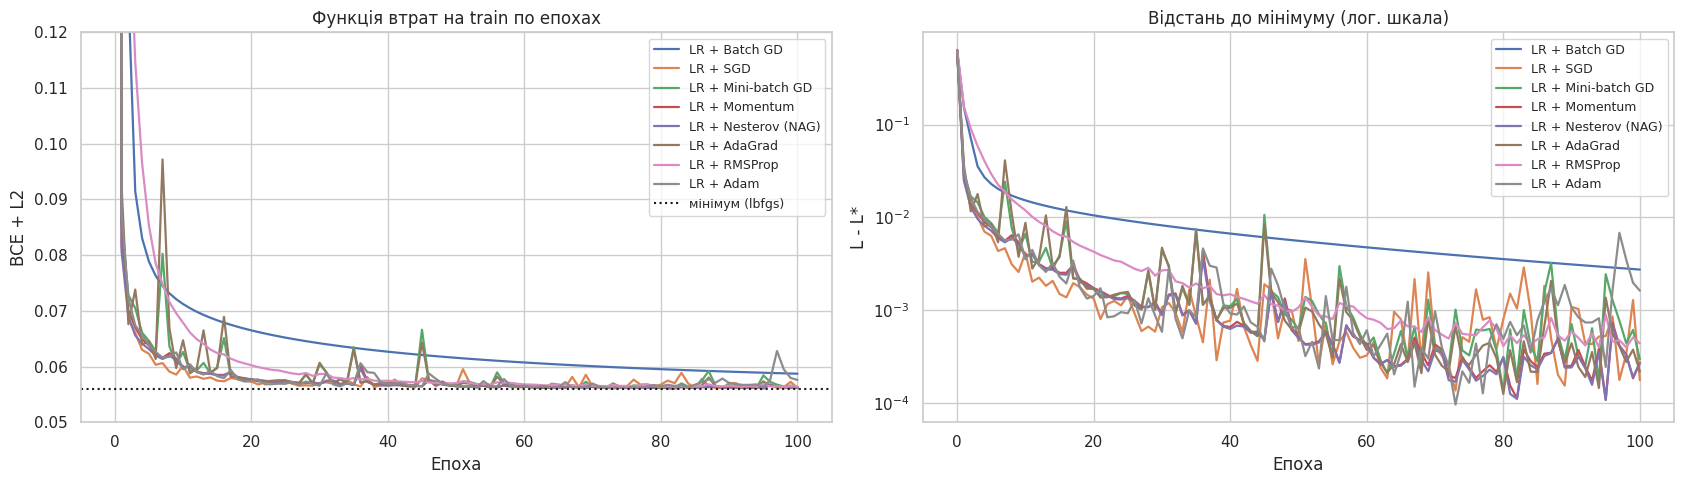

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for name, m in gd_models.items():
    axes[0].plot(m.history_, label=name, lw=1.6)
    axes[1].semilogy(np.array(m.history_) - loss_ref + 1e-6, label=name, lw=1.6)
axes[0].axhline(loss_ref, color='k', ls=':', label='мінімум (lbfgs)')
axes[0].set_ylim(0.05, 0.12)
axes[0].set_title('Функція втрат на train по епохах'); axes[0].set_xlabel('Епоха'); axes[0].set_ylabel('BCE + L2')
axes[1].set_title('Відстань до мінімуму (лог. шкала)'); axes[1].set_xlabel('Епоха'); axes[1].set_ylabel('L - L*')
for ax in axes: ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

### 7.3. Траєкторії методів оптимізації у 2D (PC1, PC2)

Щоб наочно побачити поведінку оптимізаторів, навчаємо логістичну регресію лише на двох головних компонентах без зсуву
(2 параметри $w_1, w_2$, L2-регуляризація $\lambda = 0.05$, щоб мінімум був скінченним) і малюємо траєкторії на лініях рівня функції втрат.

Мінімум (scipy): [-1.892  0.546] L* = 0.372


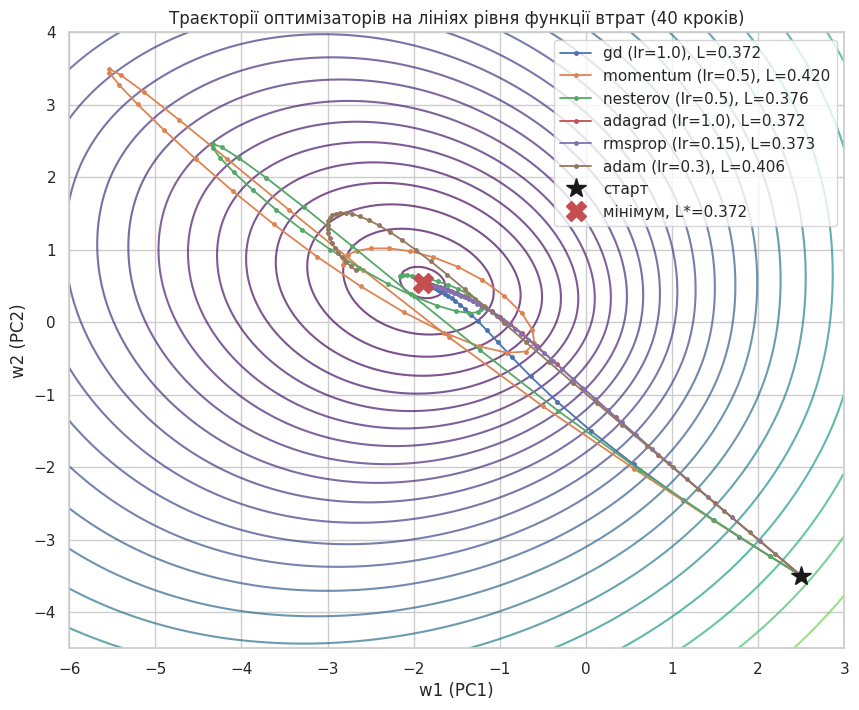

In [34]:
X2 = X_train_pca[:, :2] / X_train_pca[:, :2].std(axis=0)

LAM2 = 0.05
def loss2(w):  return bce_loss(np.r_[w, 0.0], add_bias(X2), y_train, LAM2)
def grad2(w):  return bce_grad(np.r_[w, 0.0], add_bias(X2), y_train, LAM2)[:2]

from scipy.optimize import minimize
w_star = minimize(loss2, np.zeros(2), jac=grad2).x
print('Мінімум (scipy):', w_star.round(3), 'L* =', round(loss2(w_star), 4))

def trajectory(method, lr, steps=40, w0=(2.5, -3.5), beta=0.9, rho=0.9, b1=0.9, b2=0.999, eps=1e-8):
    w = np.array(w0, float); v = np.zeros(2); s = np.zeros(2); path = [w.copy()]
    for t in range(1, steps + 1):
        if method == 'nesterov':
            g = grad2(w - beta * v)
        else:
            g = grad2(w)
        if method == 'gd':        w = w - lr * g
        elif method in ('momentum', 'nesterov'):
            v = beta * v + lr * g; w = w - v
        elif method == 'adagrad':
            s += g ** 2; w = w - lr * g / (np.sqrt(s) + eps)
        elif method == 'rmsprop':
            s = rho * s + (1 - rho) * g ** 2; w = w - lr * g / (np.sqrt(s) + eps)
        elif method == 'adam':
            v = b1 * v + (1 - b1) * g; s = b2 * s + (1 - b2) * g ** 2
            w = w - lr * (v / (1 - b1 ** t)) / (np.sqrt(s / (1 - b2 ** t)) + eps)
        path.append(w.copy())
    return np.array(path)

w1, w2 = np.meshgrid(np.linspace(-6, 3, 140), np.linspace(-4.5, 4, 140))
Z = np.array([loss2(np.array([a, b])) for a, b in zip(w1.ravel(), w2.ravel())]).reshape(w1.shape)

plt.figure(figsize=(10, 8))
cs = plt.contour(w1, w2, Z, levels=np.logspace(np.log10(loss2(w_star)) + 0.005, 0.7, 25), cmap='viridis', alpha=0.7)
for (method, lr), c in zip([('gd', 1.0), ('momentum', 0.5), ('nesterov', 0.5), ('adagrad', 1.0),
                            ('rmsprop', 0.15), ('adam', 0.3)],
                           ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']):
    p = trajectory(method, lr)
    plt.plot(p[:, 0], p[:, 1], 'o-', ms=2.5, lw=1.3, color=c,
             label=f'{method} (lr={lr}), L={loss2(p[-1]):.3f}')
plt.plot(2.5, -3.5, 'k*', ms=15, label='старт')
plt.plot(*w_star, 'rX', ms=14, label=f'мінімум, L*={loss2(w_star):.3f}')
plt.xlabel('w1 (PC1)'); plt.ylabel('w2 (PC2)')
plt.title('Траєкторії оптимізаторів на лініях рівня функції втрат (40 кроків)')
plt.legend(); plt.show()

**Висновки кроку 7:**
- **Усі методи градієнтного спуску збігаються** до тієї самої точки, що й lbfgs: функція втрат через 100 епох відрізняється від мінімуму
  (0.0560) лише на 0.0002–0.003, а тестова якість (F1 = 0.986, accuracy = 98.25%) збігається з `sklearn LogisticRegression` для 6 з 8 методів.
- **Batch GD** — найстабільніший (гладка крива), але найповільніший за епохами: одне оновлення на епоху, після 100 епох ще найдалі від мінімуму (gap ≈ 0.003).
- **SGD** — найшвидше зменшує втрати за епохами (455 оновлень/епоху), але найдовший за часом (≈ 0.66 c через цикл по одному прикладу)
  і **найбільш «шумний»** біля мінімуму — потрібне зменшення learning rate з часом.
- **Mini-batch GD** — оптимальний компроміс між швидкістю збіжності, стабільністю та часом (векторизація по батчу).
- **Momentum і Nesterov** — прискорюють рух уздовж «долини» функції втрат; на 2D-траєкторіях видно, що Momentum
  «проскакує» мінімум і робить петлю, а **Nesterov** завдяки «погляду вперед» гасить коливання і швидше стабілізується.
- **AdaGrad** — адаптивний крок для кожного параметра; на цій опуклій задачі збігається швидко і стабільно (накопичення $G$ природно зменшує крок).
- **RMSProp** — надійний, але з обраним lr повільніше стартує (loss на 5-й епосі 0.085).
- **Adam** — швидкий старт, але з постійним lr = 0.05 коливається біля мінімуму (фінальний loss 0.0576 > loss на 20-й епосі),
  через що тестова F1 трохи нижча (0.972); на 2D-траєкторії теж видно характерну «спіраль» навколо мінімуму. Зниження lr або lr-schedule це виправляє.
- Для цієї **опуклої і добре обумовленої** (після стандартизації) задачі переваги «просунутих» оптимізаторів невеликі — усі методи знаходять
  глобальний мінімум; різниця — у швидкості та стабільності. Ключові чинники успіху — **стандартизація ознак і підбір learning rate**.

## Крок 8. Логістична регресія з оптимізацією параметрів генетичним алгоритмом (PyGAD)

**Хромосома** — вектор параметрів $\theta = (w_1, …, w_n, b)$ (дійсні гени).
**Фітнес-функція** — те, що максимізуємо. Порівнюємо два варіанти:
- **accuracy** на train (як у прикладі) — кусково-стала функція, «плато» без підказок про напрямок;
- **$-$BCE** (мінус крос-ентропія з L2) — гладка функція, що враховує не лише правильність, а й «впевненість» передбачення.

ГА — метод нульового порядку (не використовує градієнт), тому його ефективність сильно залежить від розмірності простору пошуку.
Тому ГА запускаємо у двох просторах ознак: **30 ознак (31 ген)** і **PCA-простір** (компоненти, що пояснюють 95% дисперсії).

In [35]:
def make_fitness(Xb, y, kind='bce', lam=LAM):
    if kind == 'bce':
        def fitness(ga_instance, solution, solution_idx):
            return -bce_loss(solution, Xb, y, lam)
    else:
        def fitness(ga_instance, solution, solution_idx):
            return accuracy_score(y, (Xb @ solution >= 0).astype(int))
    return fitness

def run_ga(X_tr, y_tr, kind='bce', num_generations=300, sol_per_pop=50, num_parents_mating=20,
           crossover_type='uniform', mutation_type='random', mutation_probability=0.1,
           init_range=(-1.0, 1.0), mut_range=(-0.3, 0.3), parent_selection_type='tournament', seed=RANDOM_STATE,
           verbose_name=None):
    Xb = add_bias(X_tr)
    ga = pygad.GA(num_generations=num_generations,
                  sol_per_pop=sol_per_pop,
                  num_parents_mating=num_parents_mating,
                  num_genes=Xb.shape[1],
                  fitness_func=make_fitness(Xb, y_tr, kind),
                  init_range_low=init_range[0], init_range_high=init_range[1],
                  parent_selection_type=parent_selection_type, K_tournament=3,
                  keep_elitism=2,
                  crossover_type=crossover_type,
                  mutation_type=mutation_type,
                  mutation_probability=mutation_probability,
                  random_mutation_min_val=mut_range[0], random_mutation_max_val=mut_range[1],
                  random_seed=seed,
                  suppress_warnings=True)
    t = time.time(); ga.run(); ga.time_ = time.time() - t
    return ga

In [36]:
ga_runs = {}
configs = [
    ('GA (accuracy), 30 ознак', X_train, X_test, 'acc'),
    ('GA (-BCE), 30 ознак', X_train, X_test, 'bce'),
    (f'GA (accuracy), PCA-{N_PCA}', X_train_pca, X_test_pca, 'acc'),
    (f'GA (-BCE), PCA-{N_PCA}', X_train_pca, X_test_pca, 'bce'),
]
for name, Xtr, Xte, kind in configs:
    ga = run_ga(Xtr, y_train, kind=kind)
    theta, fit, _ = ga.best_solution()
    ga_runs[name] = (ga, theta, Xtr, Xte)
    predictions[f'LR + {name}'] = predict(theta, Xte)
    train_info[f'LR + {name}'] = {'time_s': ga.time_, 'train_loss': bce_loss(theta, add_bias(Xtr), y_train, LAM),
                                  'updates': ga.generations_completed}
    print(f'{name:28s} fitness={fit:.4f}  train_acc={accuracy_score(y_train, predict(theta, Xtr)):.4f}  '
          f'test_F1={f1_score(y_test, predict(theta, Xte)):.4f}  time={ga.time_:.1f}s')

GA (accuracy), 30 ознак      fitness=0.9934  train_acc=0.9934  test_F1=0.9718  time=5.0s


GA (-BCE), 30 ознак          fitness=-0.0564  train_acc=0.9890  test_F1=0.9861  time=1.3s


GA (accuracy), PCA-10        fitness=0.9912  train_acc=0.9912  test_F1=0.9718  time=4.2s


GA (-BCE), PCA-10            fitness=-0.0621  train_acc=0.9890  test_F1=0.9718  time=0.9s


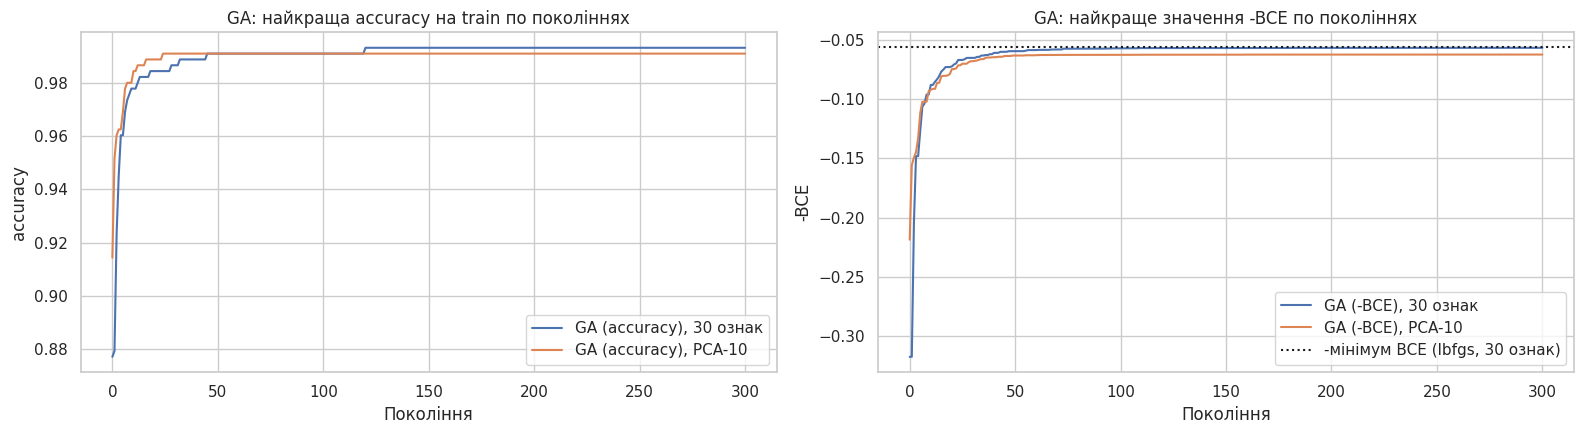

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
for name, (ga, theta, Xtr, Xte) in ga_runs.items():
    ax = axes[0] if 'accuracy' in name else axes[1]
    ax.plot(ga.best_solutions_fitness, label=name)
axes[0].set_title('GA: найкраща accuracy на train по поколіннях'); axes[0].set_ylabel('accuracy')
axes[1].set_title('GA: найкраще значення -BCE по поколіннях'); axes[1].set_ylabel('-BCE')
axes[1].axhline(-loss_ref, color='k', ls=':', label='-мінімум BCE (lbfgs, 30 ознак)')
for ax in axes: ax.set_xlabel('Покоління'); ax.legend()
plt.tight_layout(); plt.show()

### 8.1. Вплив кросовера та мутації на GA (фітнес -BCE, PCA-простір)

In [38]:
rows = []
for cx in ['single_point', 'two_points', 'uniform', 'scattered']:
    for mut in ['random', 'adaptive']:
        f1s, losses = [], []
        for seed in range(3):
            kw = dict(mutation_probability=(0.25, 0.05)) if mut == 'adaptive' else {}
            ga = run_ga(X_train_pca, y_train, kind='bce', num_generations=150, crossover_type=cx,
                        mutation_type=mut, seed=seed, **kw)
            theta = ga.best_solution()[0]
            losses.append(bce_loss(theta, add_bias(X_train_pca), y_train, LAM))
            f1s.append(f1_score(y_test, predict(theta, X_test_pca)))
        rows.append({'crossover': cx, 'mutation': mut, 'train_BCE (mean of 3)': np.mean(losses),
                     'test_F1 (mean of 3)': np.mean(f1s)})
ga_grid = pd.DataFrame(rows).sort_values('train_BCE (mean of 3)')
ga_grid.round(4)

,crossover,mutation,train_BCE (mean of 3),test_F1 (mean of 3)
0,single_point,random,0.0621,0.9718
4,uniform,random,0.0622,0.9718
6,scattered,random,0.0622,0.9718
5,uniform,adaptive,0.0622,0.9766
7,scattered,adaptive,0.0622,0.9766
2,two_points,random,0.0622,0.9766
1,single_point,adaptive,0.0622,0.9766
3,two_points,adaptive,0.0622,0.9766


In [39]:
# Гібрид: GA знаходить «хорошу стартову точку», далі доводимо її градієнтним методом (Adam)
ga_best, theta_ga, _, _ = ga_runs['GA (-BCE), 30 ознак']
# простий доналагоджувальний цикл Adam від theta_ga
theta = theta_ga.copy(); v = np.zeros_like(theta); s = np.zeros_like(theta)
Xb = add_bias(X_train); rng = np.random.default_rng(0); t = 0
for epoch in range(50):
    for b in np.array_split(rng.permutation(len(y_train)), len(y_train) // 32):
        t += 1; g = bce_grad(theta, Xb[b], y_train[b], LAM)
        v = 0.9 * v + 0.1 * g; s = 0.999 * s + 0.001 * g ** 2
        theta -= 0.01 * (v / (1 - 0.9 ** t)) / (np.sqrt(s / (1 - 0.999 ** t)) + 1e-8)
predictions['LR + GA(-BCE) -> Adam, 30 ознак'] = predict(theta, X_test)
train_info['LR + GA(-BCE) -> Adam, 30 ознак'] = {'time_s': ga_best.time_, 'train_loss': bce_loss(theta, Xb, y_train, LAM)}
print(f'BCE після GA: {bce_loss(theta_ga, Xb, y_train, LAM):.4f} -> після доналаштування Adam: '
      f'{bce_loss(theta, Xb, y_train, LAM):.4f}')
print('test F1:', round(f1_score(y_test, predictions['LR + GA(-BCE) -> Adam, 30 ознак']), 4))

BCE після GA: 0.0564 -> після доналаштування Adam: 0.0561
test F1: 0.9861


**Висновки кроку 8:**
- ГА здатен навчити логістичну регресію без обчислення градієнта: найкращий варіант (**фітнес = −BCE, 30 ознак**) за 300 поколінь
  досяг функції втрат 0.0564 (мінімум 0.0560) і тієї самої якості, що й sklearn: **F1 = 0.986, accuracy = 98.25%**.
- **Вибір фітнес-функції важливий.** Фітнес = accuracy дає найвищу точність на **train** (99.3%), але гіршу на **test** (F1 = 0.972):
  accuracy — кусково-стала функція, ГА знаходить будь-яку площину, що розділяє train, без запасу (margin) — це перенавчання,
  а BCE «штовхає» точки подалі від межі і краще узагальнює. До того ж обчислення accuracy через `accuracy_score` повільніше (≈ 5 c проти ≈ 1.3 c).
- У просторі PCA-10 (11 генів) ГА досяг loss 0.062, F1 = 0.972 — менша розмірність полегшує пошук, але PCA втрачає частину інформації.
- Тип кросовера і мутації (8.1) впливає слабко: усі комбінації дають loss ≈ 0.062 і F1 0.972–0.977; адаптивна мутація трохи стабільніша.
- **Гібридна схема GA → Adam** доводить розв'язок ГА до мінімуму (0.0564 → 0.0561): ГА корисний для глобального пошуку стартової точки,
  градієнтний метод — для точного локального доналаштування.
- Недолік ГА — **ціна**: ≈ 15 000 обчислень функції втрат (50 хромосом × 300 поколінь) і 1–5 с проти ≈ 0.003 с у lbfgs та 0.03 с у mini-batch GD.

## Крок 9. Оцінка якості кожного класифікатора: `confusion_matrix()` та `f1_score()`

Додатково (як у прикладі з конспекту) будуємо класифікатор, що використовує результат кластеризації:
**GMM → апріорні ймовірності → GaussianNB** у PCA-просторі.

> Позитивний клас у `f1_score()` за замовчуванням — `1` (benign). Оскільки в медичній задачі критично важливо
> **не пропустити злоякісну пухлину**, окремо наводимо також F1 і recall для класу `0` (malignant).

In [40]:
gmm_pca = GaussianMixture(n_components=2, n_init=10, random_state=RANDOM_STATE).fit(X_train_pca)
# зіставлення компонент GMM з класами, щоб ваги відповідали порядку класів [0, 1]
comp = gmm_pca.predict(X_train_pca)
comp_class = {c: np.bincount(y_train[comp == c], minlength=2).argmax() for c in range(2)}
priors = np.zeros(2)
for c, k in comp_class.items():
    priors[k] += gmm_pca.weights_[c]
priors = priors / priors.sum()
print('Апріорні ймовірності з y_train:', np.round(np.bincount(y_train) / len(y_train), 3),
      '| ваги GMM:', np.round(priors, 3))
gnb = GaussianNB(priors=priors).fit(X_train_pca, y_train)
predictions[f'GMM priors + GaussianNB (PCA-{N_PCA})'] = gnb.predict(X_test_pca)
train_info[f'GMM priors + GaussianNB (PCA-{N_PCA})'] = {}

Апріорні ймовірності з y_train: [0.374 0.626] | ваги GMM: [0.313 0.687]


In [41]:
rows = []
for name, y_pred in predictions.items():
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()   # класи: 0 - malignant, 1 - benign
    rows.append({'model': name,
                 'accuracy': accuracy_score(y_test, y_pred),
                 'F1 (benign=1)': f1_score(y_test, y_pred),
                 'F1 (malignant=0)': f1_score(y_test, y_pred, pos_label=0),
                 'F1 macro': f1_score(y_test, y_pred, average='macro'),
                 'recall malignant': recall_score(y_test, y_pred, pos_label=0),
                 'пропущено malignant (FN)': fp,
                 'train_loss': train_info.get(name, {}).get('train_loss', np.nan),
                 'time_s': train_info.get(name, {}).get('time_s', np.nan)})
results = pd.DataFrame(rows).sort_values(['F1 macro', 'accuracy'], ascending=False).reset_index(drop=True)
results.round(4)

,model,accuracy,F1 (benign=1),F1 (malignant=0),F1 macro,recall malignant,пропущено malignant (FN),train_loss,time_s
0,sklearn LR (30 ознак),0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0513,0.0036
1,LR + SGD,0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0562,0.6902
2,LR + Mini-batch GD,0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0563,0.0295
3,LR + Momentum,0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0562,0.0332
4,LR + Nesterov (NAG),0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0562,0.0356
5,LR + AdaGrad,0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0562,0.0314
6,LR + RMSProp,0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0564,0.0373
7,"LR + GA (-BCE), 30 ознак",0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0564,1.3239
8,"LR + GA(-BCE) -> Adam, 30 ознак",0.9825,0.9861,0.9762,0.9812,0.9762,1,0.0561,1.3239
9,sklearn LR (PCA-10),0.9737,0.9790,0.9647,0.9719,0.9762,1,0.0576,0.0023


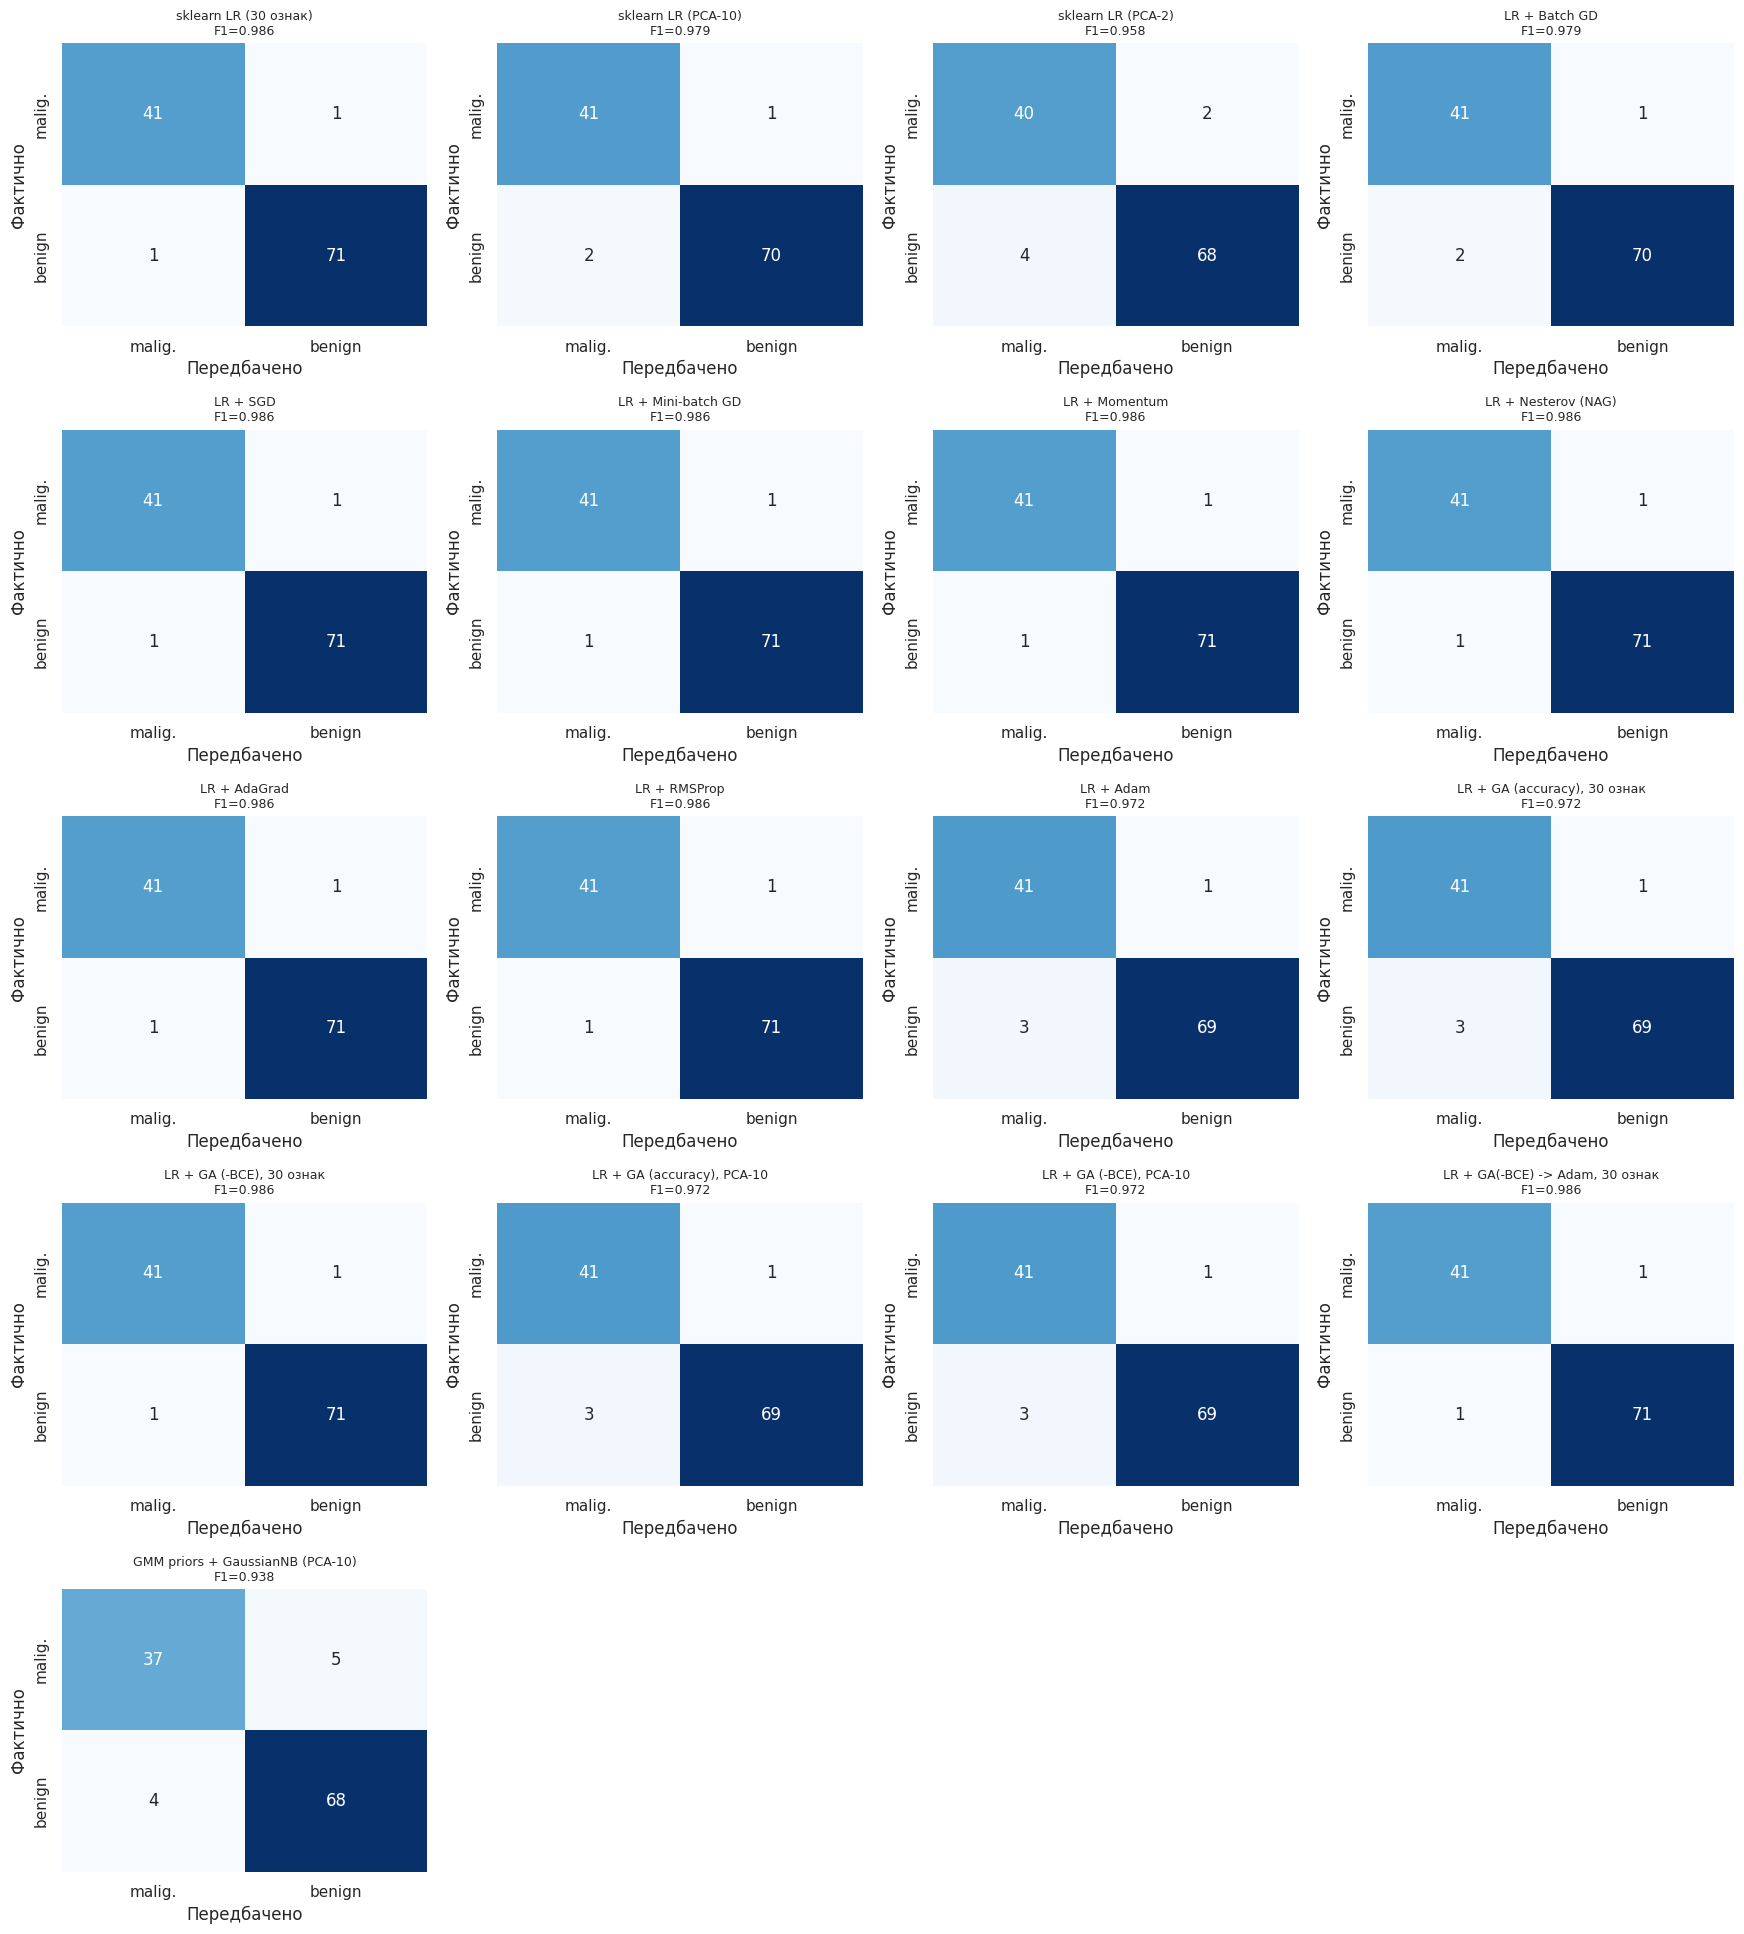

In [42]:
names = list(predictions.keys())
ncols = 4
nrows = int(np.ceil(len(names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.4 * ncols, 3.9 * nrows))
for ax, name in zip(axes.ravel(), names):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['malig.', 'benign'], yticklabels=['malig.', 'benign'])
    ax.set_title(f'{name}\nF1={f1_score(y_test, predictions[name]):.3f}', fontsize=9)
    ax.set_xlabel('Передбачено'); ax.set_ylabel('Фактично')
for ax in axes.ravel()[len(names):]:
    ax.axis('off')
plt.tight_layout(); plt.show()

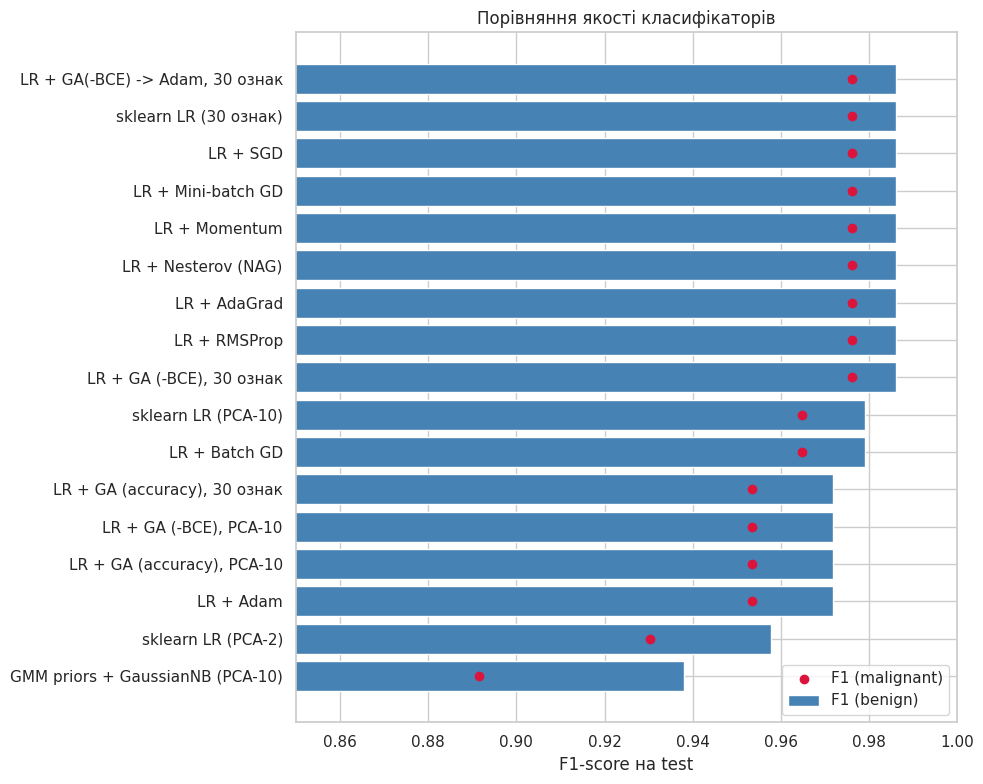

In [43]:
plt.figure(figsize=(10, 8))
r = results.sort_values('F1 (benign=1)')
plt.barh(r['model'], r['F1 (benign=1)'], color='steelblue', label='F1 (benign)')
plt.scatter(r['F1 (malignant=0)'], r['model'], color='crimson', zorder=3, label='F1 (malignant)')
plt.xlim(0.85, 1.0); plt.xlabel('F1-score на test')
plt.title('Порівняння якості класифікаторів')
plt.legend(); plt.tight_layout(); plt.show()

**Висновки кроку 9:**
- На тестовій вибірці (114 зразків: 42 злоякісні, 72 доброякісні) найкращі моделі — `sklearn LR (30 ознак)`, LR з оптимізаторами
  **SGD, Mini-batch, Momentum, Nesterov, AdaGrad, RMSProp**, а також **GA (−BCE)** та гібрид **GA → Adam**:
  **accuracy = 98.25%, F1(benign) = 0.986, F1(malignant) = 0.976**. Матриця помилок у них однакова: 1 злоякісна пухлина
  класифікована як доброякісна (FN) і 1 доброякісна — як злоякісна (FP).
- Batch GD (недонавчений за 100 епох), Adam (коливання біля мінімуму), sklearn LR на PCA-10 і GA з фітнесом accuracy —
  на 1–2 помилки більше (F1 0.972–0.979). Усі вони теж пропускають лише 1 злоякісний випадок, тобто відрізняються «зайвими» тривогами (FP).
- Логістична регресія на PCA-2 — F1 = 0.958 (2 пропущені злоякісні): двох компонент недостатньо.
- **GMM-апріорні + GaussianNB** — найслабша модель (F1 = 0.938, recall malignant = 0.88, 5 пропущених злоякісних): наївний Байєс
  припускає незалежність ознак, а ваги GMM (0.31/0.69) лише приблизно відповідають реальним апріорним імовірностям (0.37/0.63).
- Для медичної задачі важливий саме **recall класу malignant** (не пропустити рак); найкращі моделі мають recall = 97.6%.

## Крок 10. Загальні висновки про якість оптимізації параметрів класифікаторів

1. **Дані.** Breast Cancer Wisconsin — 569 зразків, 30 сильно корельованих дійсних ознак. Класи майже лінійно роздільні,
   найінформативніші ознаки — розмір і нерівність контуру ядра (concave points, perimeter, radius, area).
2. **Кластеризація** без міток відтворює діагноз з точністю 91–94% (найкраще — GMM з повною коваріацією, ARI ≈ 0.77),
   що підтверджує природну групову структуру даних. Спектральна кластеризація чутлива до вибору матриці подібності.
3. **PCA** стискає 30 ознак до 10 компонент (95% дисперсії); вже на PC1–PC2 класи майже розділені.
   Для класифікації PCA дає невелику втрату якості (F1 0.986 → 0.979), але суттєво спрощує візуалізацію та пошук ГА.
4. **Оптимізація параметрів логістичної регресії:**

| Метод оптимізації | Якість (test F1) | Швидкість / стабільність |
|---|---|---|
| lbfgs (sklearn) | 0.986 | найшвидший (≈ 20 ітерацій), точний мінімум |
| Batch GD | 0.979 | стабільний, але повільна збіжність |
| SGD | 0.986 | швидка збіжність за епохами, шумний, повільний у Python |
| Mini-batch / Momentum / Nesterov | 0.986 | найкращий баланс швидкості та стабільності |
| AdaGrad / RMSProp | 0.986 | стабільні, адаптивний крок, менш чутливі до lr |
| Adam (сталий lr) | 0.972 | швидкий старт, коливання біля мінімуму без зменшення lr |
| Генетичний алгоритм (−BCE) | 0.986 | досягає мінімуму, але у 50–500 разів дорожчий |
| Генетичний алгоритм (accuracy) | 0.972 | перенавчається на train, повільний |

5. **Головні висновки:**
   - Функція втрат логістичної регресії **опукла**, тому градієнтні методи гарантовано знаходять глобальний мінімум — і всі вони
     дають практично однакову якість, рівну sklearn. Різниця між оптимізаторами — у швидкості збіжності, стабільності та чутливості до learning rate.
   - Для гладких опуклих задач **градієнтні методи (особливо mini-batch з моментом / адаптивні) — найкращий вибір**;
     якість залежить насамперед від стандартизації ознак, регуляризації та підбору learning rate.
   - **Генетичний алгоритм** може досягти тієї ж якості, але значно дорожчий і чутливий до вибору фітнес-функції (−BCE краще, ніж accuracy)
     та розмірності простору. Він доречний для **недиференційовних** цільових функцій, дискретних параметрів, підбору гіперпараметрів
     або як глобальний пошук стартової точки для градієнтного методу (гібрид GA → Adam).
   - Найкраща отримана модель: логістична регресія на 30 стандартизованих ознаках — **accuracy 98.25%, F1 = 0.986,
     recall злоякісних 97.6%** (1 пропущений випадок з 42).